Autocorr Similarity (A vs B): 0.050
Autocorr Similarity (A vs C): 1.050
Autocorr Similarity (B vs C): 1.002


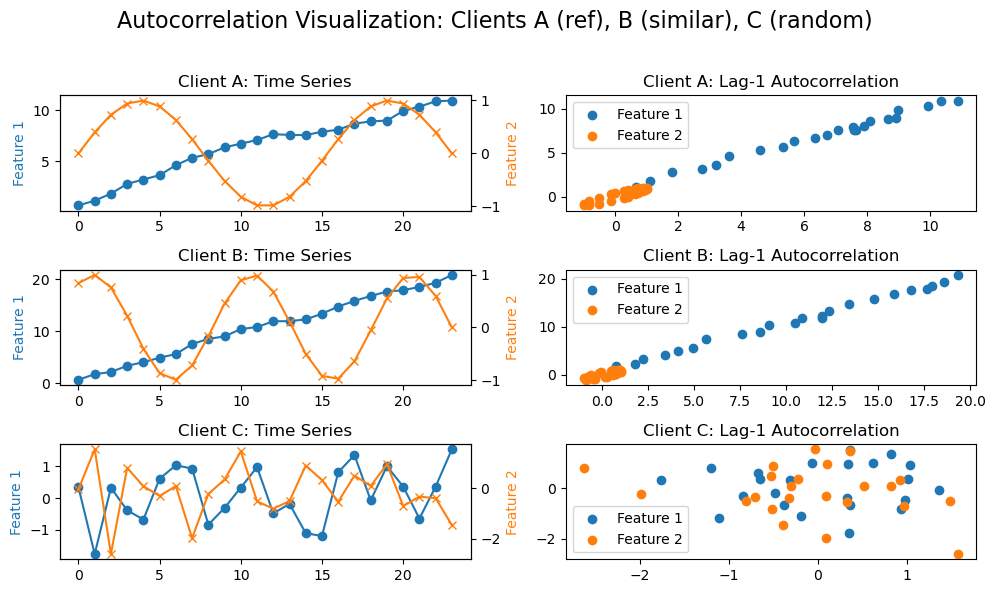

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define autocorr_similarity
def autocorr_similarity(protos_a, protos_b, lag=1):
    def autocorr(x, lag):
        n = len(x)
        if n <= lag + 1:
            return np.nan
        x1 = x[:-lag]
        x2 = x[lag:]
        if np.std(x1) == 0 or np.std(x2) == 0:
            return np.nan
        return np.corrcoef(x1, x2)[0, 1]
    
    acc = 0
    valid_counts = 0
    for i in range(protos_a.shape[1]):
        a_corr = autocorr(protos_a[:, i], lag)
        b_corr = autocorr(protos_b[:, i], lag)
        if not np.isnan(a_corr) and not np.isnan(b_corr):
            acc += abs(a_corr - b_corr)
            valid_counts += 1
    return np.nan if valid_counts == 0 else acc / valid_counts

# Seed and setup
np.random.seed(42)
T = 24
lag = 1

# Client A: smooth trend + periodic signal
feature1_a = np.cumsum(np.random.normal(loc=0.5, scale=0.3, size=T))
feature2_a = np.sin(np.linspace(0, 3 * np.pi, T))
protos_a = np.stack([feature1_a, feature2_a], axis=1)

# Client B: similar to A with some variation
feature1_b = np.cumsum(np.random.normal(loc=1, scale=0.5, size=T))
feature2_b = np.sin(np.linspace(1, 5 * np.pi, T))
protos_b = np.stack([feature1_b, feature2_b], axis=1)

# Client C: random noise
feature1_c = np.random.normal(loc=0.0, scale=1.0, size=T)
feature2_c = np.random.normal(loc=0.0, scale=1.0, size=T)
protos_c = np.stack([feature1_c, feature2_c], axis=1)

# Similarity computation
sim_ab = autocorr_similarity(protos_a, protos_b, lag=1)
sim_ac = autocorr_similarity(protos_a, protos_c, lag=1)
sim_bc = autocorr_similarity(protos_b, protos_c, lag=1)

print(f"Autocorr Similarity (A vs B): {sim_ab:.3f}")
print(f"Autocorr Similarity (A vs C): {sim_ac:.3f}")
print(f"Autocorr Similarity (B vs C): {sim_bc:.3f}")

# Helper to prepare shifted vectors for autocorr plot
def get_lagged_pairs(feature, lag=1):
    return feature[:-lag], feature[lag:]

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(10, 6))

clients = {
    'A': protos_a,
    'B': protos_b,
    'C': protos_c
}
colors = {
    'feature1': 'tab:blue',
    'feature2': 'tab:orange'
}

for idx, (client_name, proto) in enumerate(clients.items()):
    ax_ts = axes[idx, 0]  # time series
    ax_corr = axes[idx, 1]  # autocorr scatter

    # Time series with dual y-axis
    ax1 = ax_ts
    ax2 = ax1.twinx()
    ax1.plot(proto[:, 0], label='Feature 1', color=colors['feature1'], marker='o')
    ax2.plot(proto[:, 1], label='Feature 2', color=colors['feature2'], marker='x')
    ax1.set_ylabel('Feature 1', color=colors['feature1'])
    ax2.set_ylabel('Feature 2', color=colors['feature2'])
    ax_ts.set_title(f"Client {client_name}: Time Series")

    # Lag-1 autocorr scatter
    x1, y1 = get_lagged_pairs(proto[:, 0], lag)
    x2, y2 = get_lagged_pairs(proto[:, 1], lag)
    ax_corr.scatter(x1, y1, label='Feature 1', color=colors['feature1'])
    ax_corr.scatter(x2, y2, label='Feature 2', color=colors['feature2'])
    ax_corr.set_title(f"Client {client_name}: Lag-{lag} Autocorrelation")
    ax_corr.legend()

fig.suptitle("Autocorrelation Visualization: Clients A (ref), B (similar), C (random)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [1]:
CASE_TGT = 'NEW_TESTING'

In [47]:
def get_similar_districts_from_path(path_string):
    try:
        # Split the experiment name
        parts = path_string.split('__')
        
        # Get target info
        header = parts[0]  # e.g., 'E_15_LL_LM'
        target_district = header.split('_')[0]  # 'E'
        target_init_state = header.split('_')[2]  # 'LL'
        target_final_state = header.split('_')[3]  # 'LM'

        # Get district state mapping
        state_mapping_str = parts[1]  # e.g., 'LM_LL_LM_LL_LL'
        district_states = state_mapping_str.split('_')

        # Districts in order
        district_names = ['A', 'B', 'C', 'D', 'E']

        if len(district_states) < 5:
            raise ValueError("Expected at least 5 states for districts A–E. Got: " + str(district_states))

        # Map district to state
        district_state_map = dict(zip(district_names, district_states[:5]))

        # Find similar districts (excluding the target itself)
        similar_initial = [d for d, s in district_state_map.items() if s == target_init_state and d != target_district]
        similar_final = [d for d, s in district_state_map.items() if s == target_final_state and d != target_district]

        return {
            "target_district": target_district,
            "target_init_state": target_init_state,
            "target_final_state": target_final_state,
            "initial_similar_districts": similar_initial,
            "final_similar_districts": similar_final
        }

    except Exception as e:
        print(f"Error parsing: {e}")
        return None


def analyze_experiment(results_id, results_path='results'):
    try:
        info_state = get_similar_districts_from_path(results_id)
        tgt_client = results_id[0]
        path = f"{results_path}/{results_id}/Baseline_proto.parquet"

        results_proto = pd.read_parquet(path)
        results_tgt = results_proto[results_proto['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

        results_tgt['cosine_rank'] = results_tgt.groupby(['epoch', 'label'])['cosine'].rank(method='dense', ascending=True)

        # remover!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        results_tgt['test_metric'] = results_tgt['cosine'] + results_tgt['autocorr']
        results_tgt['cosine_rank'] = results_tgt.groupby(['epoch', 'label'])['test_metric'].rank(method='dense', ascending=True)


        top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

        summary = top_ranked.groupby(['epoch', 'label', 'client_2']).size().reset_index(name='count')
        summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

        summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
        summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
        summary = summary.dropna(subset=['district_letter', 'epoch', 'label'])

        # Final-only match
        summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

        # Warm-up rule
        def match_with_warmup(row):
            if row['label'] < 3:
                return row['district_letter'] in info_state['initial_similar_districts']
            else:
                return row['district_letter'] in info_state['final_similar_districts']

        summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

        # Summarize results
        total_final = summary['match_final_only'].sum()
        total_warmup = summary['match_warmup_rule'].sum()

        matches_per_epoch = summary.groupby('epoch')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
        max_final = matches_per_epoch['match_final_only'].max()
        max_warmup = matches_per_epoch['match_warmup_rule'].max()

        matches_per_epoch['experiment'] = results_id
        matches_per_epoch['max_final_matches'] = max_final
        matches_per_epoch['max_warmup_matches'] = max_warmup

        # return matches_per_epoch

        return {
            'experiment': results_id,
            'total_final_matches': total_final,
            'total_warmup_matches': total_warmup,
            'max_final_matches': max_final,
            'max_warmup_matches': max_warmup
        }

    except Exception as e:
        return {'experiment': results_id, 'error': str(e)}


In [49]:
import pandas as pd
import os
import glob
from collections import defaultdict

results_path = 'results'

# Get all folder paths
folders_with_rep = [f for f in glob.glob(os.path.join(results_path, F'*{CASE_TGT}*')) if os.path.isdir(f)]

# Group by base experiment (strip off last suffix)
grouped_exps = defaultdict(list)
for path in folders_with_rep:
    folder_name = os.path.basename(path)
    if '__' in folder_name:
        base = '__'.join(folder_name.split('__')[:-1])
        grouped_exps[base].append(path)
    else:
        grouped_exps[folder_name].append(path)

# Run analysis for each experiment folder
all_results = []
for base_name, group_paths in grouped_exps.items():
    for path in group_paths:
        exp_name = os.path.basename(path)
        result = analyze_experiment(exp_name, results_path=results_path)
        all_results.append(result)

In [50]:
# df_results = pd.concat(all_results)
# df_agg = df_results.groupby('experiment').agg({'match_final_only' : 'sum'})

# df_aux = df_agg[df_agg['match_final_only'] != 0]
# df_filter = df_agg[df_agg['match_final_only'] >= 144 ]
# df_filter.shape, df_aux.shape, df_agg.shape

In [51]:
# df_results = pd.DataFrame(all_results)

# df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
#     df_results['experiment'].apply(extract_exp_info)
# )

# df_results.head()

In [52]:
df_results = pd.DataFrame(all_results)

def extract_exp_info(exp_id):
    try:
        parts = exp_id.split('__')
        target_header = parts[0]                     # 'E_15_LL_LM'
        mapping = parts[1]                           # 'LM_LL_LM_LL_LL'

        target_district = target_header.split('_')[0]     # 'E'
        node_id = target_header.split('_')[1]             # '15'
        init_state = target_header.split('_')[2]          # 'LL'
        final_state = target_header.split('_')[3]         # 'LM'

        aux_exp1 = exp_id.split('__')[-1]
        aux_exp2 = exp_id.split('__')[-2]

        return pd.Series([
            f"{target_district}_{node_id}",         # 'E_15'
            f"{init_state}_{final_state}",          # 'LL_LM'
            mapping[:14],                                 # 'LM_LL_LM_LL_LL'
            f"{aux_exp2}_{aux_exp1}"
        ])
    except Exception as e:
        print(f"Failed parsing exp_id: {exp_id} — {e}")
        return pd.Series([None, None, None])

df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
    df_results['experiment'].apply(extract_exp_info)
)

df_sorted = df_results.sort_values(by='max_warmup_matches', ascending=False)

df_sorted['target_district'] = df_sorted['target_district_node'].str.split('_').str[0]
df_sorted['target_final_state'] = df_sorted['target_init_final_state'].str.split('_').str[-1]

df_sorted[['A', 'B', 'C', 'D', 'E']] = df_sorted['initial_state_mapping'].str.split('_', expand = True)

df_sorted.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)

def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
    return '_'.join(match_cols)

df_sorted['similar_districts'] = df_sorted.apply(find_similar, axis=1)

df_sorted.head()

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,exp_id,target_district,target_final_state,A,B,C,D,E,similar_districts
38,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_12_6_NEW_WINDO...,77,67,24,22,6_3_43200__0,A,LH,LL,LH,LL,LL,LM,B
52,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_6_9_NEW_WINDOW...,71,76,24,22,9_4_21600__0,A,LH,LL,LH,LL,LL,LM,B
238,A_62_LL_LM__LL_LH_LL_LL_LM_10_1_12_9_NEW_WINDO...,100,109,24,22,9_4_43200__0,A,LM,LL,LH,LL,LL,LM,E
239,A_62_LL_LM__LL_LH_LL_LL_LM_10_1_12_9_NEW_WINDO...,117,126,24,22,9_6_43200__0,A,LM,LL,LH,LL,LL,LM,E
50,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_6_6_NEW_WINDOW...,135,127,24,22,6_3_21600__0,A,LH,LL,LH,LL,LL,LM,B


In [53]:
df_filtered.shape

(396, 14)

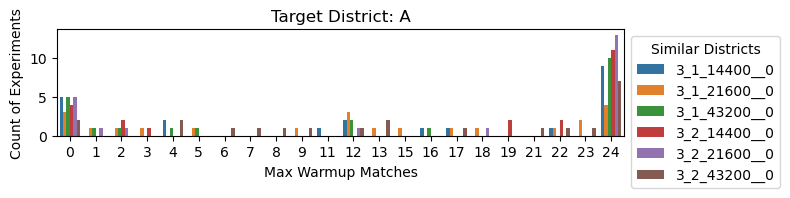

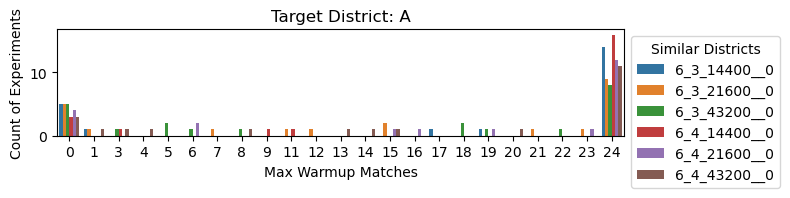

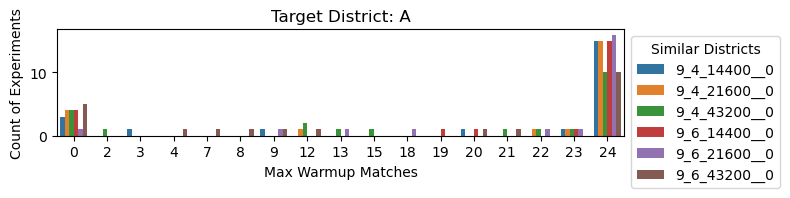

In [54]:
df_filtered = df_sorted[df_sorted['similar_districts'] != ''].copy()
df_agg = df_filtered.groupby(['exp_id', 'max_final_matches']).agg({'target_district' : 'count'}).reset_index()
df_agg['max_final_matches'] = df_agg['max_final_matches'].astype(int)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tgt = 'A'
for case in ['3', '6', '9']:
# for case in ['12', '24', '42']:
    df_plot = df_agg[df_agg['exp_id'].str.split('_').str[0] == case]
    plt.figure(figsize=(8, 2))
    sns.barplot(
        data=df_plot,
        x='max_final_matches',
        y='target_district',
        hue='exp_id',
        # hue_order=['A', 'B', 'C', 'D', 'E']
    )

    plt.title(f'Target District: {tgt}')
    plt.xlabel('Max Warmup Matches')
    plt.ylabel('Count of Experiments')
    plt.legend(title='Similar Districts', bbox_to_anchor = (1,1))
    plt.tight_layout()
    plt.show()

In [59]:
# Get max warmup match for each unique config
idx = df_results.groupby(
    ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
)['max_warmup_matches'].idxmax()

df_best_per_config = df_results.loc[idx].reset_index(drop=True)

# Optional: sort by warmup performance
df_best_per_config = df_best_per_config.sort_values(by='max_warmup_matches', ascending=False)


df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]

df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)

df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)

def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
    return '_'.join(match_cols)

df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)

# Show results
print("🏆 Best experiment per configuration (based on warm-up matches):")
# df_best_per_config[['experiment', 'max_warmup_matches', 'target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']]
df_best_per_config[df_best_per_config['similar_districts'] != '']

🏆 Best experiment per configuration (based on warm-up matches):


,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,exp_id,target_district,target_final_state,A,B,C,D,E,similar_districts
2,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_12_6_NEW_WINDO...,77,67,24,22,6_3_43200__0,A,LH,LL,LH,LL,LL,LM,B
13,A_62_LL_LM__LL_LH_LL_LL_LM_10_1_12_9_NEW_WINDO...,100,109,24,22,9_4_43200__0,A,LM,LL,LH,LL,LL,LM,E
16,A_62_LL_LM__LL_LL_LL_LH_LM_10_1_12_3_NEW_WINDO...,50,68,24,21,3_2_43200__0,A,LM,LL,LL,LL,LH,LM,E
14,A_62_LL_LM__LL_LH_LM_LL_LL_10_1_12_6_NEW_WINDO...,101,85,24,21,6_3_43200__0,A,LM,LL,LH,LM,LL,LL,C
31,A_62_LL_ML__LL_ML_HL_LM_HM_10_1_12_3_NEW_WINDO...,96,84,24,21,3_1_43200__0,A,ML,LL,ML,HL,LM,HM,B
23,A_62_LL_ML__LL_LH_HM_MH_ML_10_1_12_3_NEW_WINDO...,178,154,24,21,3_1_43200__0,A,ML,LL,LH,HM,MH,ML,E
22,A_62_LL_ML__LL_HL_ML_LH_LL_10_1_12_6_NEW_WINDO...,56,63,24,21,6_4_43200__0,A,ML,LL,HL,ML,LH,LL,C
21,A_62_LL_LM__LL_MM_HL_ML_LM_10_1_12_3_NEW_WINDO...,121,106,24,21,3_1_43200__0,A,LM,LL,MM,HL,ML,LM,E
20,A_62_LL_LM__LL_ML_HL_LM_HM_10_1_12_6_NEW_WINDO...,24,21,24,21,6_3_43200__0,A,LM,LL,ML,HL,LM,HM,D
19,A_62_LL_LM__LL_LM_LH_LL_LL_10_1_12_3_NEW_WINDO...,87,89,24,21,3_1_43200__0,A,LM,LL,LM,LH,LL,LL,B


In [63]:
df_best_per_config.loc[4]['experiment']

'A_62_LL_LH__LL_LL_LH_LM_LL_10_1_4_6_NEW_WINDOW_LL_LL_LH_LM_LL__6_4_14400___0'

In [67]:
filtered = df_best_per_config[df_best_per_config['similar_districts'] != '']
filtered['similar_districts'].value_counts().sort_index()

similar_districts
B    5
C    5
D    7
E    5
Name: count, dtype: int64

In [69]:
best_filter = df_best_per_config[df_best_per_config['max_warmup_matches'] >= 12]
best_filter['similar_districts'].value_counts().sort_index()

similar_districts
B    5
C    5
D    7
E    5
Name: count, dtype: int64

In [19]:
best_filter.groupby(['target_district', 'similar_districts']).agg({'exp_id' : 'count'})

exp_id
target_district similar_districts        
A               B                       2
                C                       2
                E                       1

In [21]:
df_results.sort_values(by='max_final_matches', ascending = False)

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,target_district_node,target_init_final_state,initial_state_mapping,exp_id
248,A_62_LL_ML__LL_ML_HL_LM_HM_10_1_4_6_NEW_WINDOW...,221,191,24,21,A_62,LL_ML,LL_ML_HL_LM_HM,6_3_14400__0
154,A_62_LL_LM__LL_LM_LH_LL_LL_10_1_4_6_NEW_WINDOW...,168,140,19,16,A_62,LL_LM,LL_LM_LH_LL_LL,6_3_14400__0
251,A_62_LL_ML__LL_ML_HL_LM_HM_10_1_4_9_NEW_WINDOW...,179,149,19,16,A_62,LL_ML,LL_ML_HL_LM_HM,9_6_14400__0
147,A_62_LL_LM__LL_LL_LM_LH_LL_10_1_4_6_NEW_WINDOW...,169,141,18,15,A_62,LL_LM,LL_LL_LM_LH_LL,6_4_14400__0
52,A_62_LL_LH__LL_LL_LL_LM_LH_10_1_4_9_NEW_WINDOW...,149,133,17,14,A_62,LL_LH,LL_LL_LL_LM_LH,9_4_14400__0
...,...,...,...,...,...,...,...,...,...
169,A_62_LL_LM__LL_MM_HL_ML_LM_10_1_4_3_NEW_WINDOW...,0,0,0,0,A_62,LL_LM,LL_MM_HL_ML_LM,3_2_14400__0
168,A_62_LL_LM__LL_MM_HL_ML_LM_10_1_4_3_NEW_WINDOW...,0,0,0,0,A_62,LL_LM,LL_MM_HL_ML_LM,3_1_14400__0
125,A_62_LL_LM__LL_LL_LH_LM_LL_10_1_4_9_NEW_WINDOW...,0,0,0,0,A_62,LL_LM,LL_LL_LH_LM_LL,9_6_14400__0
59,A_62_LL_LH__LL_LL_LM_LH_LL_10_1_4_6_NEW_WINDOW...,0,28,0,3,A_62,LL_LH,LL_LL_LM_LH_LL,6_4_14400__0


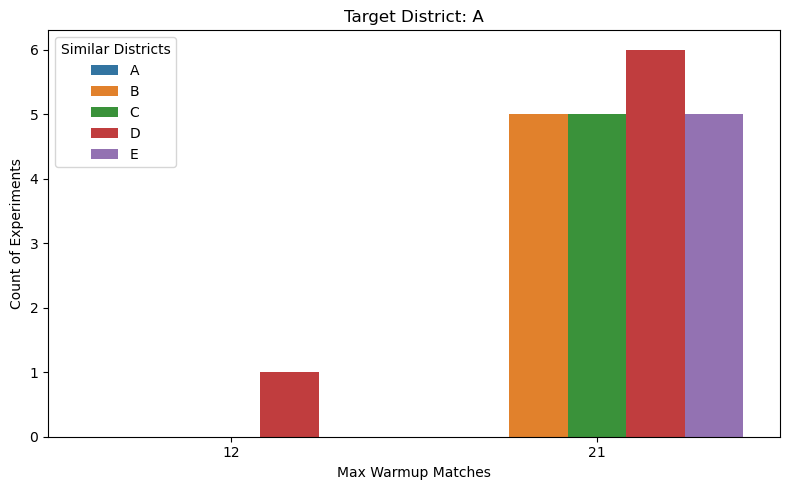

In [65]:
df_plot = df_best_per_config[df_best_per_config['similar_districts'].isin(['A', 'B', 'C', 'D', 'E'])].groupby(['target_district', 'similar_districts', 'max_warmup_matches']).agg({'exp_id' : 'count'}).reset_index()

import seaborn as sns
import matplotlib.pyplot as plt


tgt_dict = df_best_per_config['target_district'].unique().tolist()
tgt_dict = sorted(tgt_dict)
tgt_dict = [d for d in tgt_dict if d != '']

for tgt in tgt_dict:
    aux_plot = df_plot[df_plot['target_district'] == tgt]
    
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=aux_plot,
        x='max_warmup_matches',
        y='exp_id',
        hue='similar_districts',
        hue_order=['A', 'B', 'C', 'D', 'E']
    )
    plt.title(f'Target District: {tgt}')
    plt.xlabel('Max Warmup Matches')
    plt.ylabel('Count of Experiments')
    plt.legend(title='Similar Districts')
    plt.tight_layout()
    plt.show()

In [13]:
def get_similar_districts_from_path(path_string):
    try:
        # Split the experiment name
        parts = path_string.split('__')
        
        # Get target info
        header = parts[0]  # e.g., 'E_15_LL_LM'
        target_district = header.split('_')[0]  # 'E'
        target_init_state = header.split('_')[2]  # 'LL'
        target_final_state = header.split('_')[3]  # 'LM'

        # Get district state mapping
        state_mapping_str = parts[1]  # e.g., 'LM_LL_LM_LL_LL'
        district_states = state_mapping_str.split('_')

        # Districts in order
        district_names = ['A', 'B', 'C', 'D', 'E']

        if len(district_states) < 5:
            raise ValueError("Expected at least 5 states for districts A–E. Got: " + str(district_states))

        # Map district to state
        district_state_map = dict(zip(district_names, district_states[:5]))

        # Find similar districts (excluding the target itself)
        similar_initial = [d for d, s in district_state_map.items() if s == target_init_state and d != target_district]
        similar_final = [d for d, s in district_state_map.items() if s == target_final_state and d != target_district]

        return {
            "target_district": target_district,
            "target_init_state": target_init_state,
            "target_final_state": target_final_state,
            "initial_similar_districts": similar_initial,
            "final_similar_districts": similar_final
        }

    except Exception as e:
        print(f"Error parsing: {e}")
        return None


def analyze_experiment(results_id, epoch_tgt = 0, results_path='results'):

    info_state = get_similar_districts_from_path(results_id)
    tgt_client = results_id[0]
    path = f"{results_path}/{results_id}/Baseline_proto.parquet"

    results_proto = pd.read_parquet(path)

    results_tgt = results_proto[results_proto['epoch'] == str(epoch_tgt)]
    results_tgt = results_tgt[results_tgt['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['cosine'].rank(method='dense', ascending=True)

    # remover!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    results_tgt['test_metric'] = results_tgt['cosine'] + results_tgt['autocorr']
    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['test_metric'].rank(method='dense', ascending=True)


    
    top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

    summary = top_ranked.groupby(['label', 'client_2']).size().reset_index(name='count')
    summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

    # summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
    summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
    summary = summary.dropna(subset=['district_letter', 'label'])

    # Final-only match
    summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

    # Warm-up rule
    def match_with_warmup(row):
        if row['label'] < 3:
            return row['district_letter'] in info_state['initial_similar_districts']
        else:
            return row['district_letter'] in info_state['final_similar_districts']

    summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

    # Summarize results
    total_final = summary['match_final_only'].sum()
    total_warmup = summary['match_warmup_rule'].sum()
        
    matches_per_epoch = summary.groupby('client_2')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
    max_final = matches_per_epoch['match_final_only'].max()
    max_warmup = matches_per_epoch['match_warmup_rule'].max()

    matches_per_epoch['experiment'] = results_id
    matches_per_epoch['max_final_matches'] = max_final
    matches_per_epoch['max_warmup_matches'] = max_warmup

    # return matches_per_epoch

    return {
        'experiment': results_id,
        'total_final_matches': total_final,
        'total_warmup_matches': total_warmup,
        'max_final_matches': max_final,
        'max_warmup_matches': max_warmup
    }


🏆 Best experiment per configuration (based on warm-up matches):


0


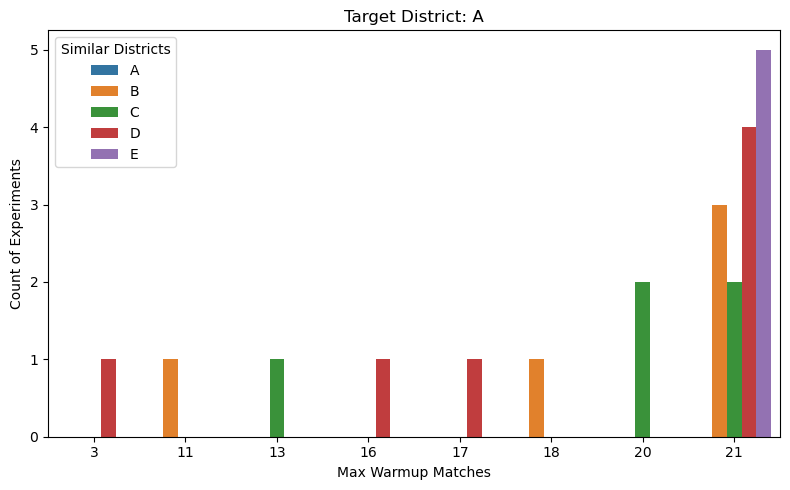

🏆 Best experiment per configuration (based on warm-up matches):


1


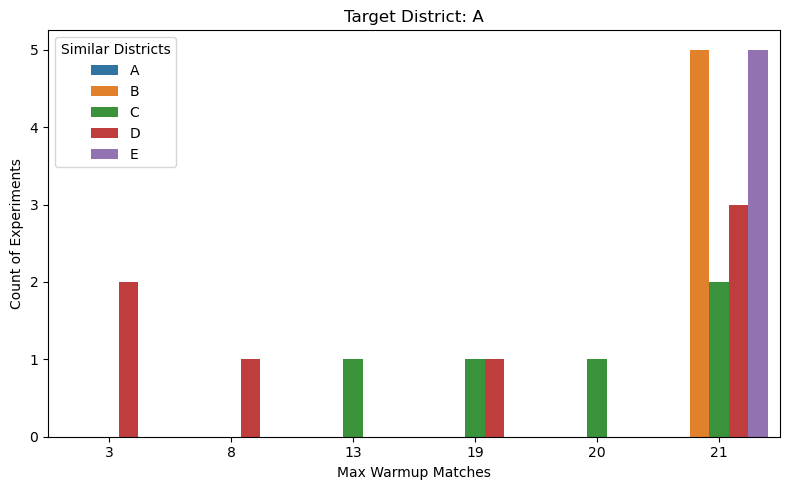

🏆 Best experiment per configuration (based on warm-up matches):


2


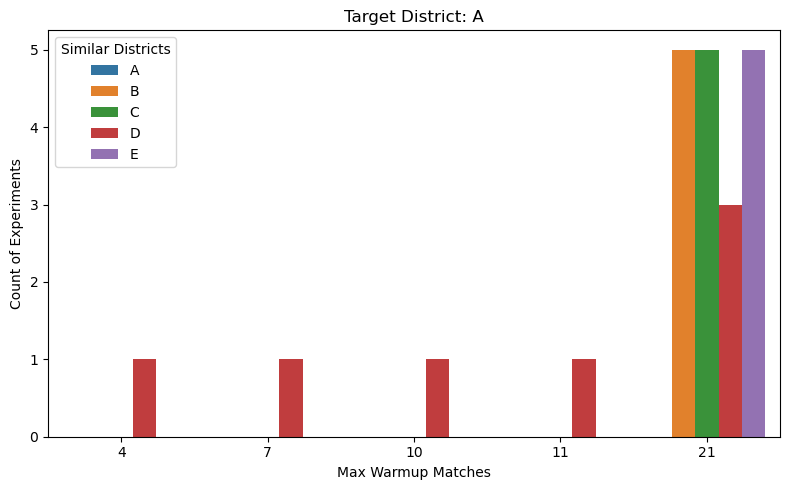

🏆 Best experiment per configuration (based on warm-up matches):


3


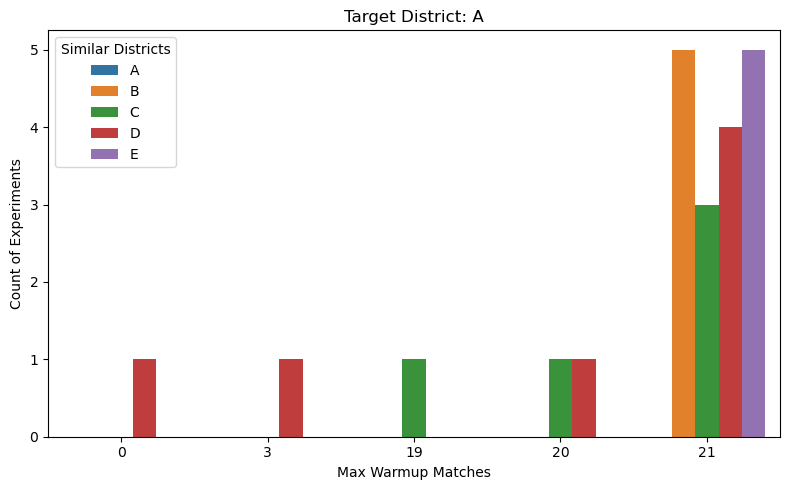

🏆 Best experiment per configuration (based on warm-up matches):


4


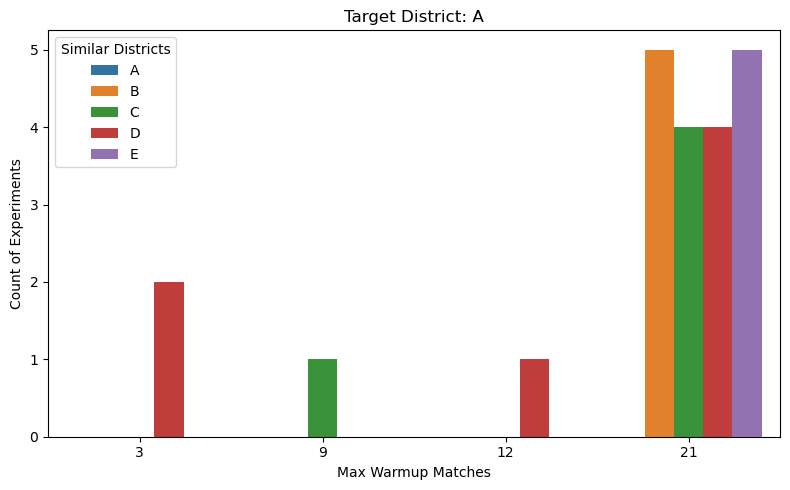

🏆 Best experiment per configuration (based on warm-up matches):


5


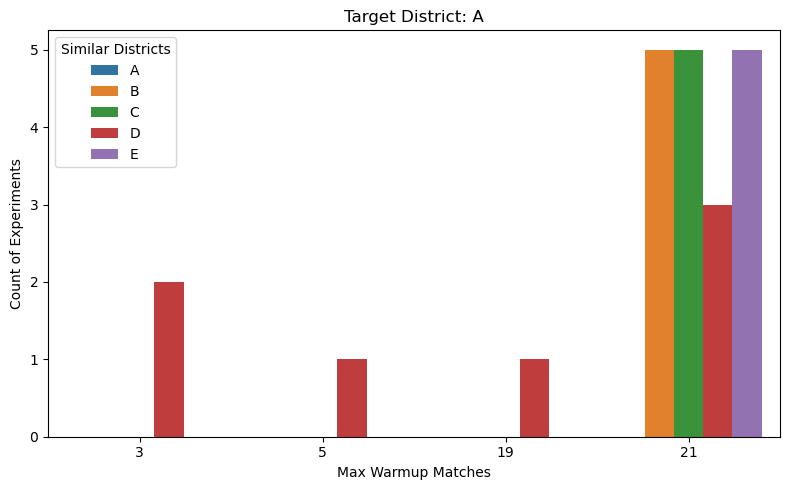

🏆 Best experiment per configuration (based on warm-up matches):


6


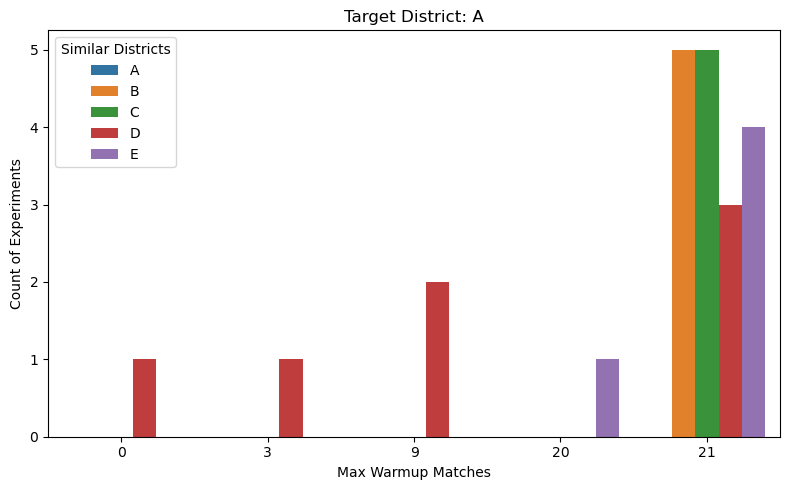

🏆 Best experiment per configuration (based on warm-up matches):


7


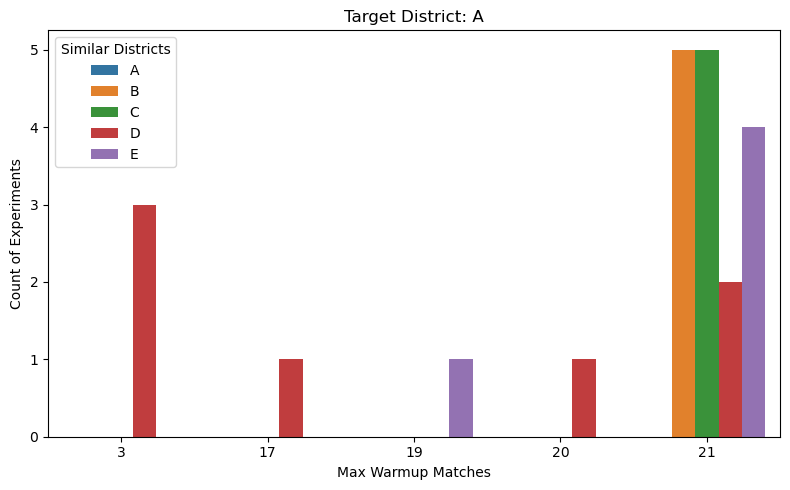

🏆 Best experiment per configuration (based on warm-up matches):


8


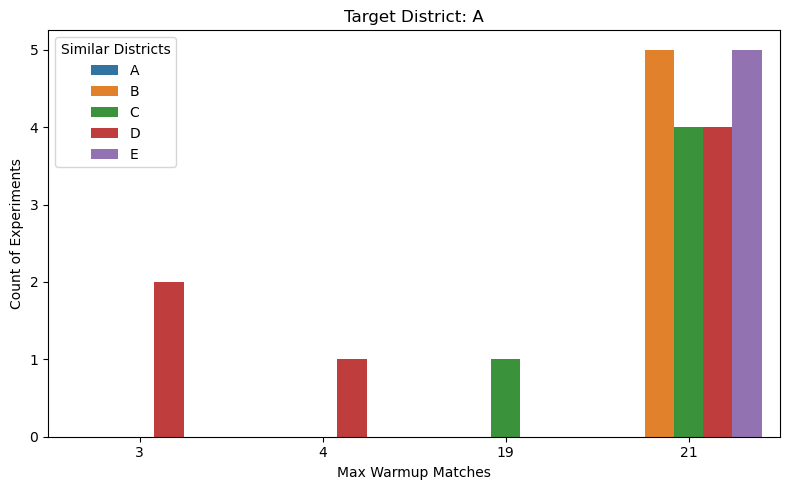

🏆 Best experiment per configuration (based on warm-up matches):


9


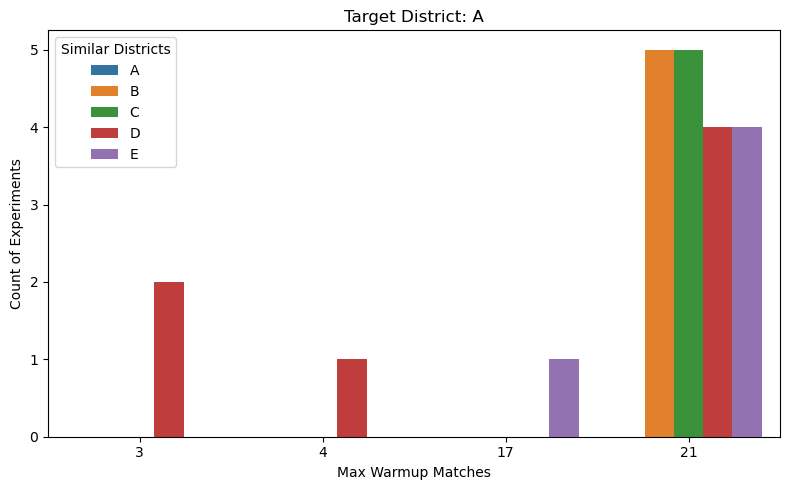

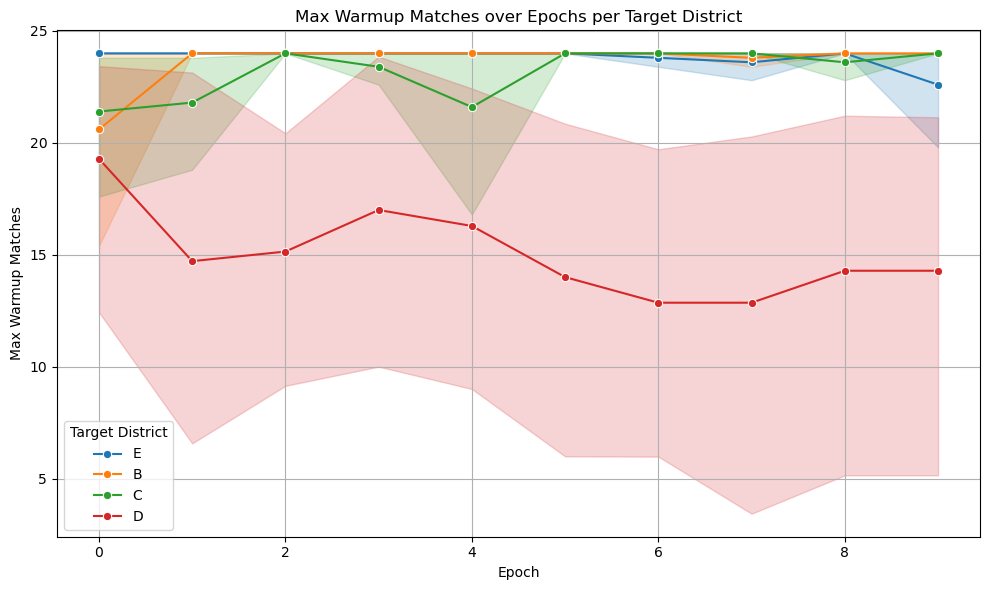

In [15]:
import pandas as pd
import os
import glob
from collections import defaultdict

CASE_TGT = 'NEW_WINDOW'

epoch_results = []

for ep_tgt in range(0,10):
        
    results_path = 'results'
    
    # Get all folder paths
    folders_with_rep = [f for f in glob.glob(os.path.join(results_path, F'*{CASE_TGT}*')) if os.path.isdir(f)]
    
    # Group by base experiment (strip off last suffix)
    grouped_exps = defaultdict(list)
    for path in folders_with_rep:
        folder_name = os.path.basename(path)
        if '__' in folder_name:
            base = '__'.join(folder_name.split('__')[:-1])
            grouped_exps[base].append(path)
        else:
            grouped_exps[folder_name].append(path)
    
    # Run analysis for each experiment folder
    all_results = []
    for base_name, group_paths in grouped_exps.items():
        for path in group_paths:
            exp_name = os.path.basename(path)
            result = analyze_experiment(exp_name, epoch_tgt = ep_tgt, results_path=results_path)
            all_results.append(result)
    
    
    
    df_results = pd.DataFrame(all_results)
    
    def extract_exp_info(exp_id):
        try:
            parts = exp_id.split('__')
            target_header = parts[0]                     # 'E_15_LL_LM'
            mapping = parts[1]                           # 'LM_LL_LM_LL_LL'
    
            target_district = target_header.split('_')[0]     # 'E'
            node_id = target_header.split('_')[1]             # '15'
            init_state = target_header.split('_')[2]          # 'LL'
            final_state = target_header.split('_')[3]         # 'LM'
    
            aux_exp1 = exp_id.split('__')[-1]
            aux_exp2 = exp_id.split('__')[-2]
    
            return pd.Series([
                f"{target_district}_{node_id}",         # 'E_15'
                f"{init_state}_{final_state}",          # 'LL_LM'
                mapping[:14],                                 # 'LM_LL_LM_LL_LL'
                f"{aux_exp2}_{aux_exp1}"
            ])
        except Exception as e:
            print(f"Failed parsing exp_id: {exp_id} — {e}")
            return pd.Series([None, None, None])
    
    df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
        df_results['experiment'].apply(extract_exp_info)
    )
    
  
    
    # Get max warmup match for each unique config
    idx = df_results.groupby(
        ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
    )['max_warmup_matches'].idxmax()
    
    df_best_per_config = df_results.loc[idx].reset_index(drop=True)
    
    # Optional: sort by warmup performance
    df_best_per_config = df_best_per_config.sort_values(by='max_warmup_matches', ascending=False)
    
    
    df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
    df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]
    
    df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)
    
    df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)
    
    def find_similar(row):
        match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
        return '_'.join(match_cols)
    
    df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)

    df_best_per_config['epoch'] = ep_tgt
    epoch_results.append(df_best_per_config.copy())

    
    # Show results
    print("🏆 Best experiment per configuration (based on warm-up matches):")
    # df_best_per_config[['experiment', 'max_warmup_matches', 'target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']]
    
    
    df_plot = df_best_per_config[df_best_per_config['similar_districts'].isin(['A', 'B', 'C', 'D', 'E'])].groupby(['target_district', 'similar_districts', 'max_warmup_matches']).agg({'exp_id' : 'count'}).reset_index()
    
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    
    tgt_dict = df_best_per_config['target_district'].unique().tolist()
    tgt_dict = sorted(tgt_dict)
    tgt_dict = [d for d in tgt_dict if d != '']

    print(f'\n\n{ep_tgt}')
    for tgt in tgt_dict:
        aux_plot = df_plot[df_plot['target_district'] == tgt]
        
        plt.figure(figsize=(8, 5))
        sns.barplot(
            data=aux_plot,
            x='max_warmup_matches',
            y='exp_id',
            hue='similar_districts',
            hue_order=['A', 'B', 'C', 'D', 'E']
        )
        plt.title(f'Target District: {tgt}')
        plt.xlabel('Max Warmup Matches')
        plt.ylabel('Count of Experiments')
        plt.legend(title='Similar Districts')
        plt.tight_layout()
        plt.show()


df_all_epochs = pd.concat(epoch_results, ignore_index=True)

df_filter = df_all_epochs[df_all_epochs['similar_districts'] != '']

# df_agg = df_filter.groupby(['similar_districts', 'epoch']).agg({'total_warmup_matches' : 'sum'}).reset_index()
# case_counts = epoch_results[0]['similar_districts'].value_counts().reset_index()
# df_plot = pd.merge(df_agg, case_counts, on = 'similar_districts', how = 'left')
# df_plot['mean_matches'] = df_plot['total_warmup_matches'] / df_plot['count']

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_filter,
    x='epoch',
    y='max_final_matches',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

🏆 Best experiment per configuration (based on warm-up matches):


0


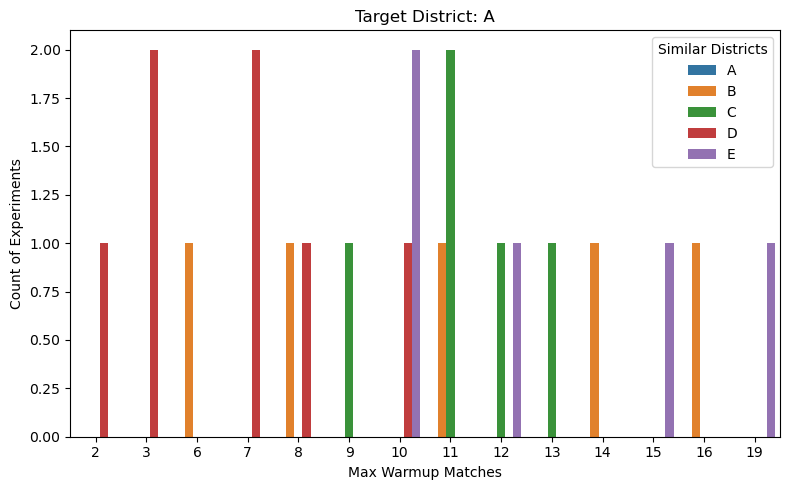

🏆 Best experiment per configuration (based on warm-up matches):


1


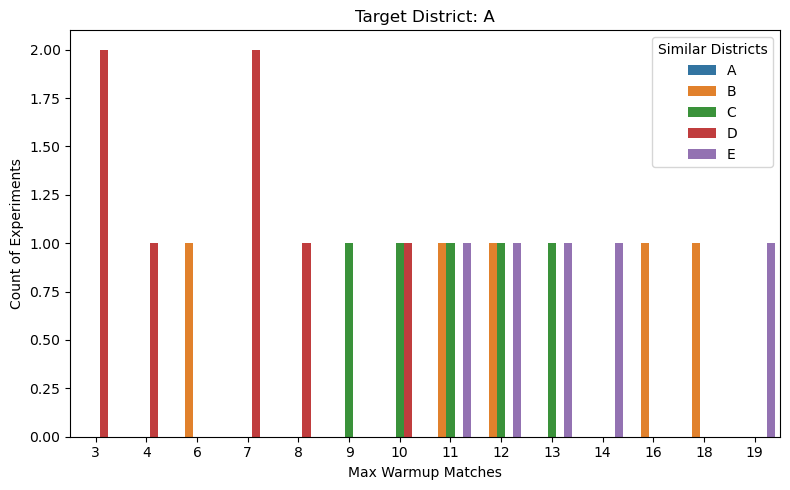

🏆 Best experiment per configuration (based on warm-up matches):


2


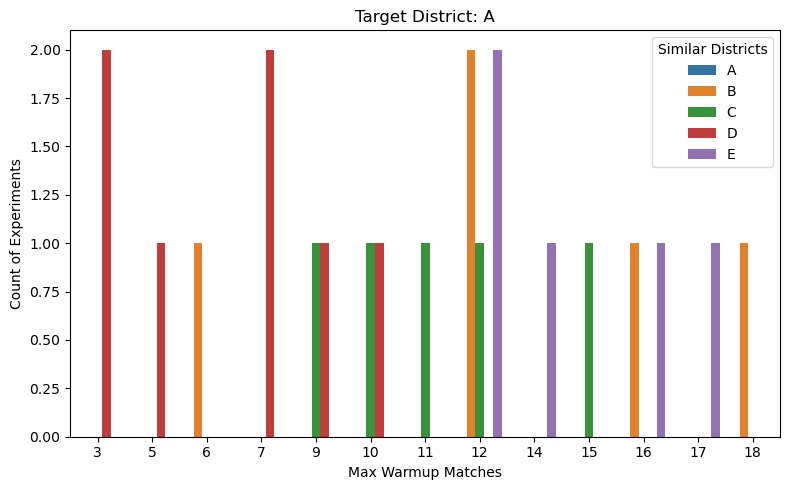

🏆 Best experiment per configuration (based on warm-up matches):


3


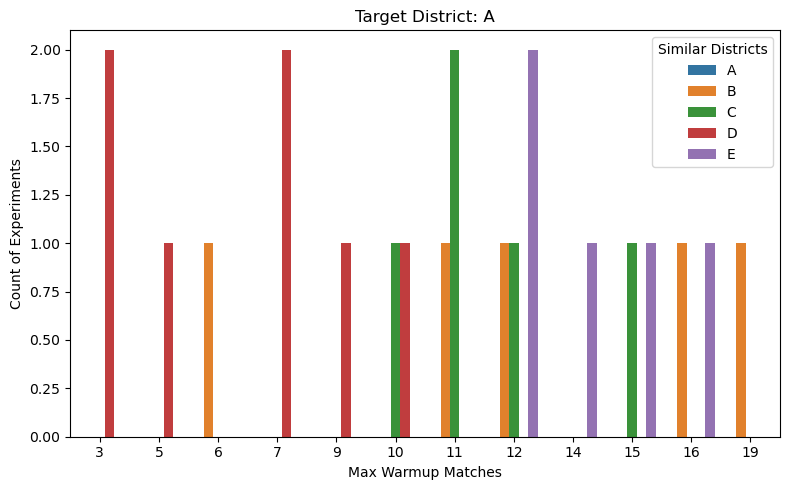

🏆 Best experiment per configuration (based on warm-up matches):


4


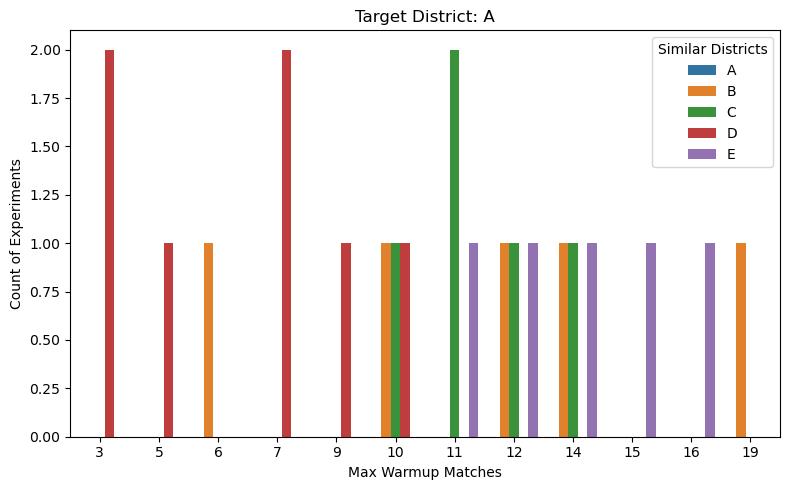

🏆 Best experiment per configuration (based on warm-up matches):


5


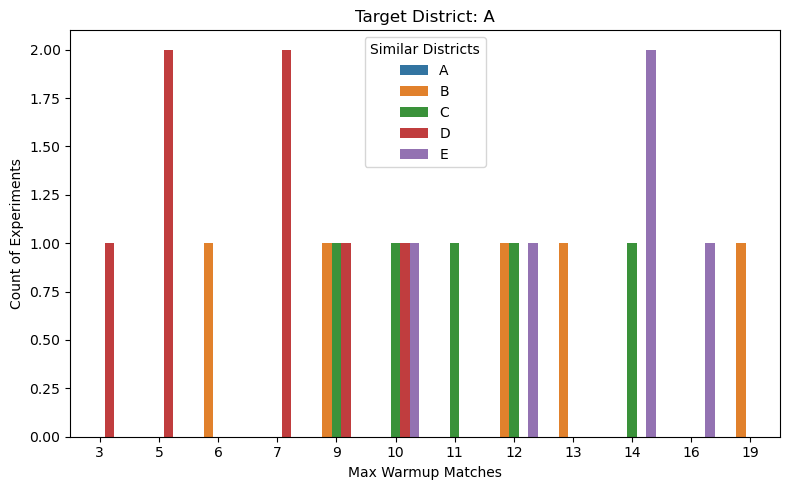

🏆 Best experiment per configuration (based on warm-up matches):


6


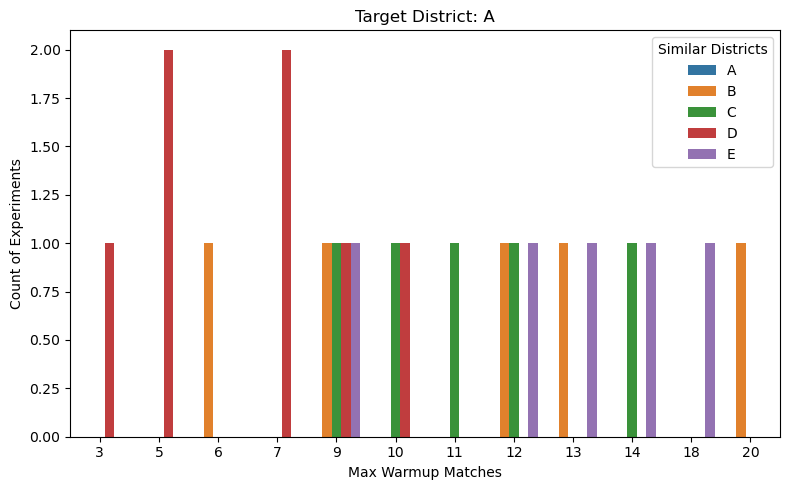

🏆 Best experiment per configuration (based on warm-up matches):


7


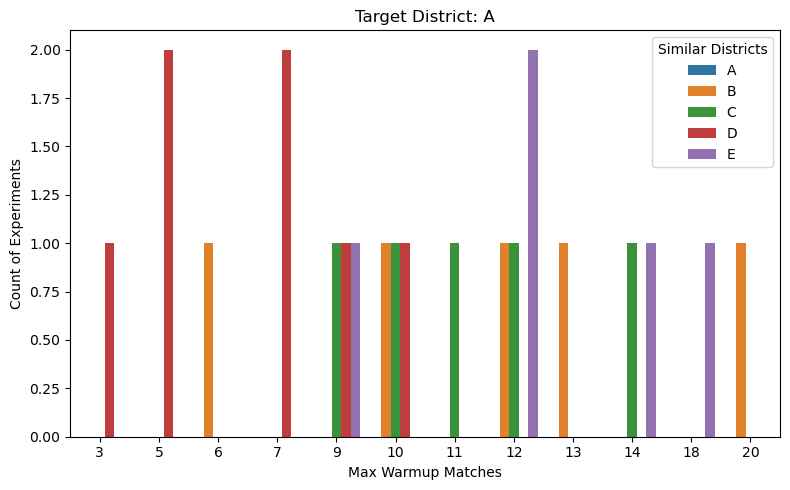

🏆 Best experiment per configuration (based on warm-up matches):


8


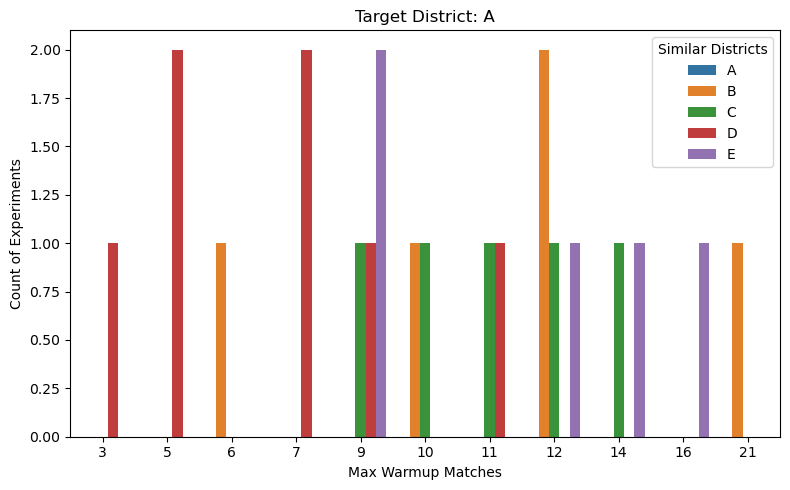

🏆 Best experiment per configuration (based on warm-up matches):


9


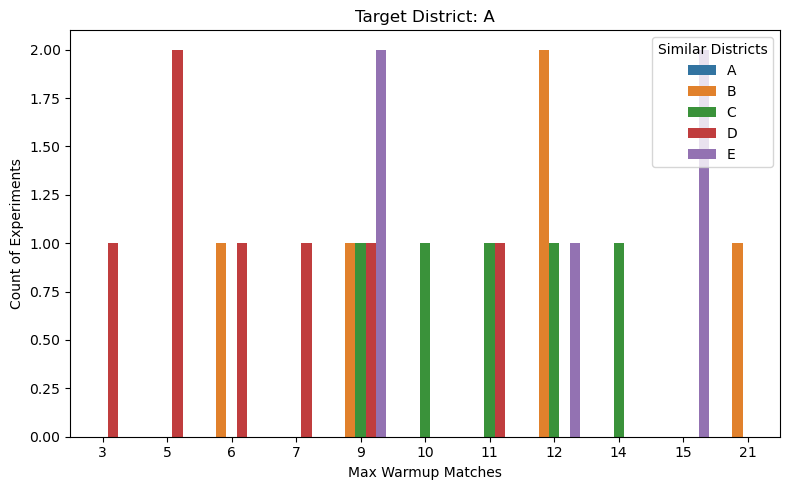

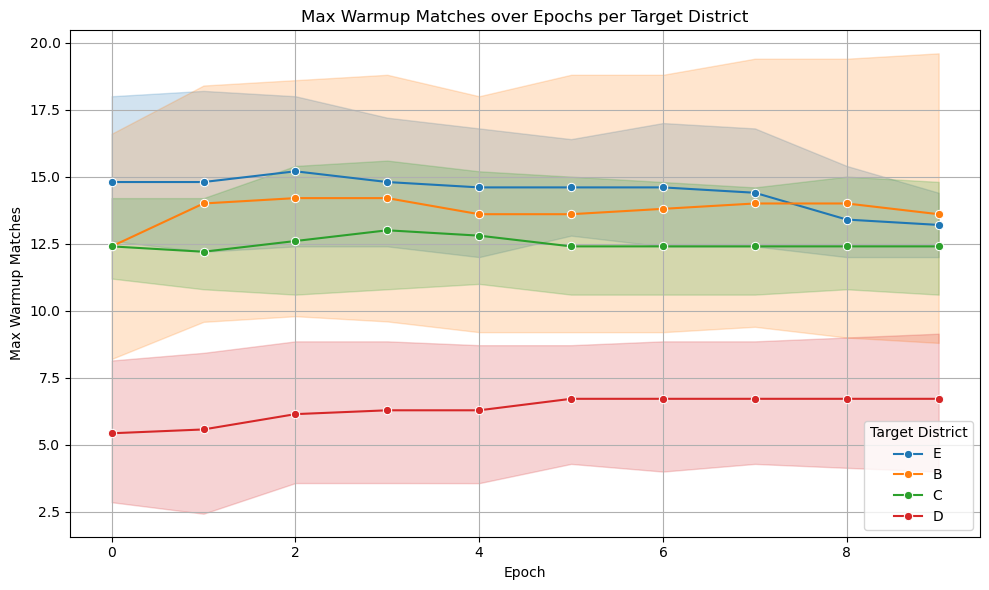

In [2]:
def get_similar_districts_from_path(path_string):
    try:
        # Split the experiment name
        parts = path_string.split('__')
        
        # Get target info
        header = parts[0]  # e.g., 'E_15_LL_LM'
        target_district = header.split('_')[0]  # 'E'
        target_init_state = header.split('_')[2]  # 'LL'
        target_final_state = header.split('_')[3]  # 'LM'

        # Get district state mapping
        state_mapping_str = parts[1]  # e.g., 'LM_LL_LM_LL_LL'
        district_states = state_mapping_str.split('_')

        # Districts in order
        district_names = ['A', 'B', 'C', 'D', 'E']

        if len(district_states) < 5:
            raise ValueError("Expected at least 5 states for districts A–E. Got: " + str(district_states))

        # Map district to state
        district_state_map = dict(zip(district_names, district_states[:5]))

        # Find similar districts (excluding the target itself)
        similar_initial = [d for d, s in district_state_map.items() if s == target_init_state and d != target_district]
        similar_final = [d for d, s in district_state_map.items() if s == target_final_state and d != target_district]

        return {
            "target_district": target_district,
            "target_init_state": target_init_state,
            "target_final_state": target_final_state,
            "initial_similar_districts": similar_initial,
            "final_similar_districts": similar_final
        }

    except Exception as e:
        print(f"Error parsing: {e}")
        return None


def analyze_experiment(results_id, epoch_tgt = 0, results_path='results'):

    info_state = get_similar_districts_from_path(results_id)
    tgt_client = results_id[0]
    path = f"{results_path}/{results_id}/Baseline_proto.parquet"

    results_proto = pd.read_parquet(path)

    results_tgt = results_proto[results_proto['epoch'] == str(epoch_tgt)]
    results_tgt = results_tgt[results_tgt['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['cosine'].rank(method='dense', ascending=True)

    
    top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

    summary = top_ranked.groupby(['label', 'client_2']).size().reset_index(name='count')
    summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

    # summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
    summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
    summary = summary.dropna(subset=['district_letter', 'label'])

    # Final-only match
    summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

    # Warm-up rule
    def match_with_warmup(row):
        if row['label'] < 3:
            return row['district_letter'] in info_state['initial_similar_districts']
        else:
            return row['district_letter'] in info_state['final_similar_districts']

    summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

    # Summarize results
    total_final = summary['match_final_only'].sum()
    total_warmup = summary['match_warmup_rule'].sum()
        
    matches_per_epoch = summary.groupby('client_2')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
    max_final = matches_per_epoch['match_final_only'].max()
    max_warmup = matches_per_epoch['match_warmup_rule'].max()

    matches_per_epoch['experiment'] = results_id
    matches_per_epoch['max_final_matches'] = max_final
    matches_per_epoch['max_warmup_matches'] = max_warmup

    # return matches_per_epoch

    return {
        'experiment': results_id,
        'total_final_matches': total_final,
        'total_warmup_matches': total_warmup,
        'max_final_matches': max_final,
        'max_warmup_matches': max_warmup
    }


import pandas as pd
import os
import glob
from collections import defaultdict

CASE_TGT = 'NEW_WINDOW'

epoch_results = []

for ep_tgt in range(0,10):
        
    results_path = 'results'
    
    # Get all folder paths
    folders_with_rep = [f for f in glob.glob(os.path.join(results_path, F'*{CASE_TGT}*')) if os.path.isdir(f)]
    
    # Group by base experiment (strip off last suffix)
    grouped_exps = defaultdict(list)
    for path in folders_with_rep:
        folder_name = os.path.basename(path)
        if '__' in folder_name:
            base = '__'.join(folder_name.split('__')[:-1])
            grouped_exps[base].append(path)
        else:
            grouped_exps[folder_name].append(path)
    
    # Run analysis for each experiment folder
    all_results = []
    for base_name, group_paths in grouped_exps.items():
        for path in group_paths:
            exp_name = os.path.basename(path)
            result = analyze_experiment(exp_name, epoch_tgt = ep_tgt, results_path=results_path)
            all_results.append(result)
    
    
    
    df_results = pd.DataFrame(all_results)
    
    def extract_exp_info(exp_id):
        try:
            parts = exp_id.split('__')
            target_header = parts[0]                     # 'E_15_LL_LM'
            mapping = parts[1]                           # 'LM_LL_LM_LL_LL'
    
            target_district = target_header.split('_')[0]     # 'E'
            node_id = target_header.split('_')[1]             # '15'
            init_state = target_header.split('_')[2]          # 'LL'
            final_state = target_header.split('_')[3]         # 'LM'
    
            aux_exp1 = exp_id.split('__')[-1]
            aux_exp2 = exp_id.split('__')[-2]
    
            return pd.Series([
                f"{target_district}_{node_id}",         # 'E_15'
                f"{init_state}_{final_state}",          # 'LL_LM'
                mapping[:14],                                 # 'LM_LL_LM_LL_LL'
                f"{aux_exp2}_{aux_exp1}"
            ])
        except Exception as e:
            print(f"Failed parsing exp_id: {exp_id} — {e}")
            return pd.Series([None, None, None])
    
    df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
        df_results['experiment'].apply(extract_exp_info)
    )
    
  
    
    # Get max warmup match for each unique config
    idx = df_results.groupby(
        ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
    )['max_warmup_matches'].idxmax()
    
    df_best_per_config = df_results.loc[idx].reset_index(drop=True)
    
    # Optional: sort by warmup performance
    df_best_per_config = df_best_per_config.sort_values(by='max_warmup_matches', ascending=False)
    
    
    df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
    df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]
    
    df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)
    
    df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)
    
    def find_similar(row):
        match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
        return '_'.join(match_cols)
    
    df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)

    df_best_per_config['epoch'] = ep_tgt
    epoch_results.append(df_best_per_config.copy())

    
    # Show results
    print("🏆 Best experiment per configuration (based on warm-up matches):")
    # df_best_per_config[['experiment', 'max_warmup_matches', 'target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']]
    
    
    df_plot = df_best_per_config[df_best_per_config['similar_districts'].isin(['A', 'B', 'C', 'D', 'E'])].groupby(['target_district', 'similar_districts', 'max_warmup_matches']).agg({'exp_id' : 'count'}).reset_index()
    
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    
    tgt_dict = df_best_per_config['target_district'].unique().tolist()
    tgt_dict = sorted(tgt_dict)
    tgt_dict = [d for d in tgt_dict if d != '']

    print(f'\n\n{ep_tgt}')
    for tgt in tgt_dict:
        aux_plot = df_plot[df_plot['target_district'] == tgt]
        
        plt.figure(figsize=(8, 5))
        sns.barplot(
            data=aux_plot,
            x='max_warmup_matches',
            y='exp_id',
            hue='similar_districts',
            hue_order=['A', 'B', 'C', 'D', 'E']
        )
        plt.title(f'Target District: {tgt}')
        plt.xlabel('Max Warmup Matches')
        plt.ylabel('Count of Experiments')
        plt.legend(title='Similar Districts')
        plt.tight_layout()
        plt.show()


df_all_epochs = pd.concat(epoch_results, ignore_index=True)

df_filter = df_all_epochs[df_all_epochs['similar_districts'] != '']

# df_agg = df_filter.groupby(['similar_districts', 'epoch']).agg({'total_warmup_matches' : 'sum'}).reset_index()
# case_counts = epoch_results[0]['similar_districts'].value_counts().reset_index()
# df_plot = pd.merge(df_agg, case_counts, on = 'similar_districts', how = 'left')
# df_plot['mean_matches'] = df_plot['total_warmup_matches'] / df_plot['count']

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_filter,
    x='epoch',
    y='max_final_matches',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
df_filtered = df_best_per_config[df_best_per_config['similar_districts'] != '']
df_filtered.head()

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,exp_id,target_district,target_final_state,A,B,C,D,E,similar_districts,epoch
31,A_62_LL_ML__LL_ML_HL_LM_HM_10_1_4_6_NEW_WINDOW...,24,21,24,21,6_3_14400__0,A,ML,LL,ML,HL,LM,HM,B,9
16,A_62_LL_LM__LL_LL_LL_LH_LM_10_1_12_3_NEW_WINDO...,15,18,15,15,3_2_43200__0,A,LM,LL,LL,LL,LH,LM,E,9
6,A_62_LL_LH__LL_LL_LL_LM_LH_10_1_12_3_NEW_WINDO...,15,18,15,15,3_2_43200__0,A,LH,LL,LL,LL,LM,LH,E,9
18,A_62_LL_LM__LL_LL_LM_LH_LL_10_1_4_6_NEW_WINDOW...,17,14,17,14,6_4_14400__0,A,LM,LL,LL,LM,LH,LL,C,9
1,A_62_LL_LH__LL_LH_HM_MH_ML_10_1_4_6_NEW_WINDOW...,12,12,12,12,6_3_14400__0,A,LH,LL,LH,HM,MH,ML,B,9


In [6]:
for results_id in df_filtered['experiment'].unique():
    print(results_id)
    break

A_62_LL_ML__LL_ML_HL_LM_HM_10_1_4_6_NEW_WINDOW_LL_ML_HL_LM_HM__6_3_14400___0


In [297]:
import os
import pickle
import warnings

import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from datasets import get_private_dataset
from utils.Server import local_evaluate
from utils.Toolbox_analysis import create_latent_df, process_latent_df
from utils.Toolbox_postprocessing import proto_analysis, distributions_analysis
from utils.Toolbox_visualization import load_and_scale_data, combine_latents, plot_latent_heatmap, plot_time_series_and_latents
from utils.Toolbox_visualization import plot_proto_similar, plot_distribution_similar

warnings.simplefilter(action='ignore', category=FutureWarning)

from utils.args import create_experiment_args, add_federated_args
from argparse import Namespace

for results_id in df_filtered['experiment'].unique():
    results_dir = f"results/{results_id}"
    
    results_path = f"{results_dir}/results.pkl"
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    
    
    args = results['Baseline']['args']
    label_clients = [
        'District_A', 'District_B', 'District_C', 'District_D', 'District_E',
        'District_2A', 'District_2B', 'District_2C'
    ]
    
    priv_dataset = get_private_dataset(args)
    backbones_list = priv_dataset.get_backbone(
        parti_num=args.parti_num,
        names_list=None,
        n_series=args.input_size
    )
    
    train_DL = priv_dataset.get_data_loaders()
    base_index = train_DL[0]['X_index']
    latent_dfs = {}
    scenarios = ['Baseline']
            
    
    all_latents = defaultdict(list)
    all_protos = defaultdict(list)
    all_dists = defaultdict(list)
    all_pca = defaultdict(list)
    all_umap = defaultdict(list)
    
    for scenario in scenarios:
        global_model_history = results[scenario]['model']['global_weights_history']
        
        iterator = tqdm(range(args.communication_epoch))
        for epoch in iterator:
            aux_latents = []
            state_dict = global_model_history[epoch]
            for net in backbones_list:
                net.load_state_dict(state_dict)
    
            latent_spaces = local_evaluate(model=backbones_list,
                                           train_dl=train_DL,
                                           private_dataset=priv_dataset,
                                           group_detections=False,
                                           detect_anomalies=False)
    
            for i, client in enumerate(latent_spaces):
                client_lat = create_latent_df(
                    X_index=base_index,
                    x_lat=client,
                    label=f"{label_clients[i]}__{epoch}",
                    is_unix=True
                )
                aux_latents.append(client_lat)
    
            data_latent = pd.concat(aux_latents)
            data_latent[['client_id', 'epoch']] = data_latent['label'].str.split('__', expand=True)
    
            # Extract year and month
            years = data_latent['timestamp'].dt.year
            months = data_latent['timestamp'].dt.month
    
            # Compute base year from the minimum timestamp
            base_year = data_latent['timestamp'].min().year
    
            # Continuous month index
            data_latent['label'] = (years - base_year) * 12 + (months - 1)
    
            id_cols = ['client_id', 'label', 'epoch']
            feat_cols = [col for col in data_latent.columns if 'x_' in col]
            aux_agg = data_latent[id_cols + feat_cols]
            aux_agg = aux_agg.groupby(id_cols).mean().reset_index()
            aux_agg = aux_agg.sort_values(by=['epoch', 'label', 'client_id']).reset_index(drop=True)
            aux_agg['client_id'] += '__proto'
    
            tag = f"{scenario}_{epoch}"
    
            aux_agg = aux_agg[aux_agg['label'] < 5]
            
            df_exp_proto = proto_analysis(data_latent=aux_agg, normalize=False)
            aux_df = df_exp_proto.copy()
            aux_df.columns = ['epoch', 'label', 'client_2', 'client_1', 'cosine', 'manhattan', 'wavelet', 'dft', 'autocorr']
            
            df_exp_proto = pd.concat([df_exp_proto, aux_df[df_exp_proto.columns.tolist()]])
            df_exp_proto = df_exp_proto.sort_values(by=['epoch', 'label', 'client_1', 'client_2']).reset_index(drop=True)

            all_protos[scenario].append(df_exp_proto)

    for scenario in scenarios:
        # pd.concat(all_latents[scenario], ignore_index=True).to_parquet(f"{results_dir}/{scenario}_latent_space.parquet", index=False) VOLTAR ESSE
        pd.concat(all_protos[scenario], ignore_index=True).to_parquet(f"{results_dir}/{scenario}_proto_initial.parquet", index=False)



100%|██████████| 10/10 [00:02<00:00,  4.91it/s]


🏆 Best experiment per configuration (based on warm-up matches):


0


,max_initial_matches,exp_id,percentage
0,0,14,87.5
1,5,2,12.5


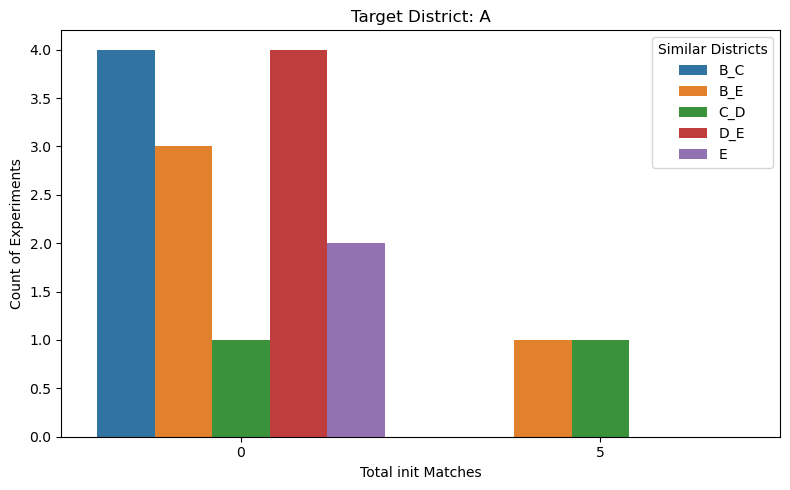

🏆 Best experiment per configuration (based on warm-up matches):


1


,max_initial_matches,exp_id,percentage
0,0,13,81.25
1,5,3,18.75


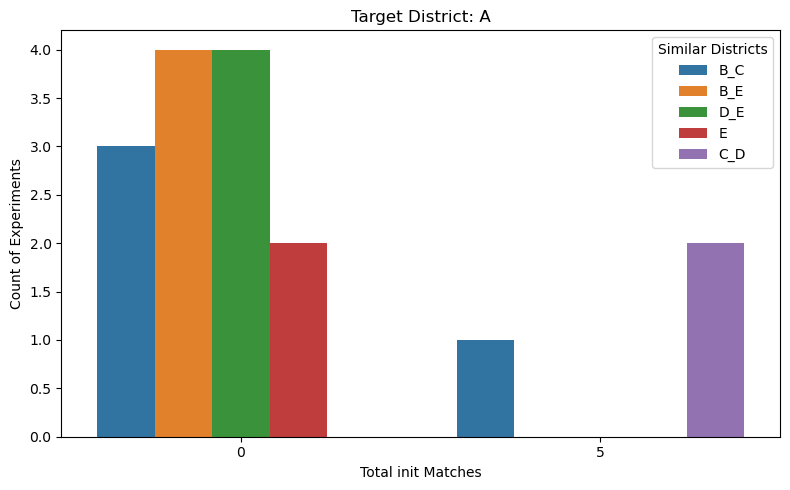

🏆 Best experiment per configuration (based on warm-up matches):


2


,max_initial_matches,exp_id,percentage
0,0,10,62.5
1,5,6,37.5


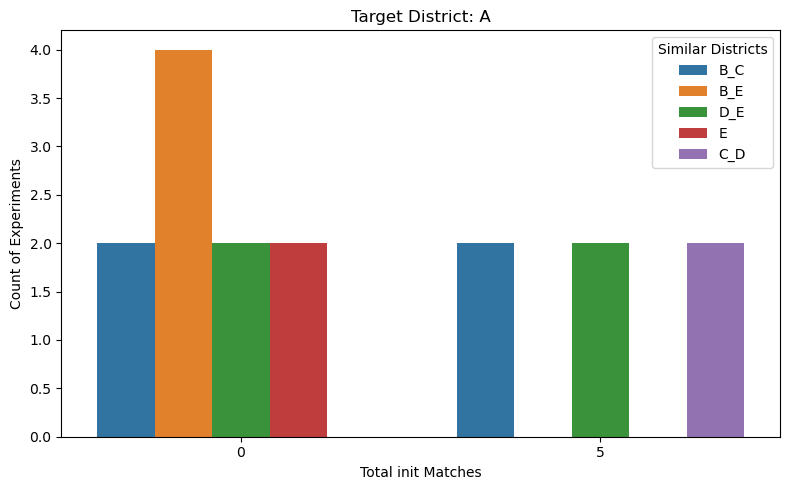

🏆 Best experiment per configuration (based on warm-up matches):


3


,max_initial_matches,exp_id,percentage
0,0,10,62.5
1,5,6,37.5


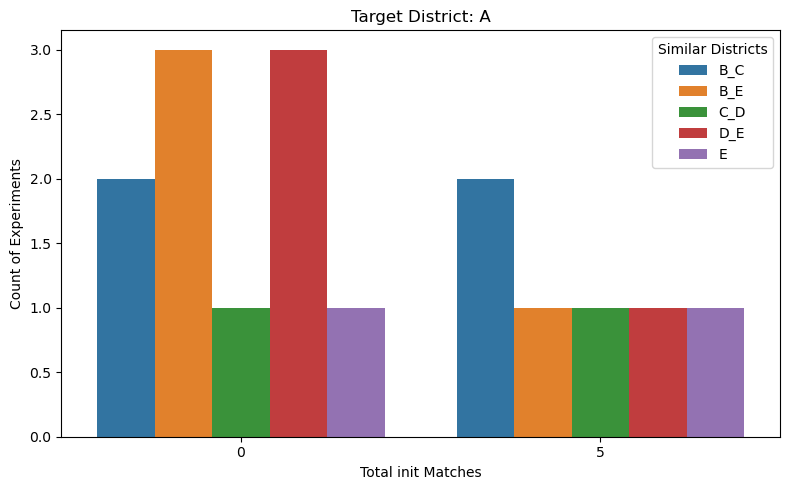

🏆 Best experiment per configuration (based on warm-up matches):


4


,max_initial_matches,exp_id,percentage
0,0,11,68.75
1,5,5,31.25


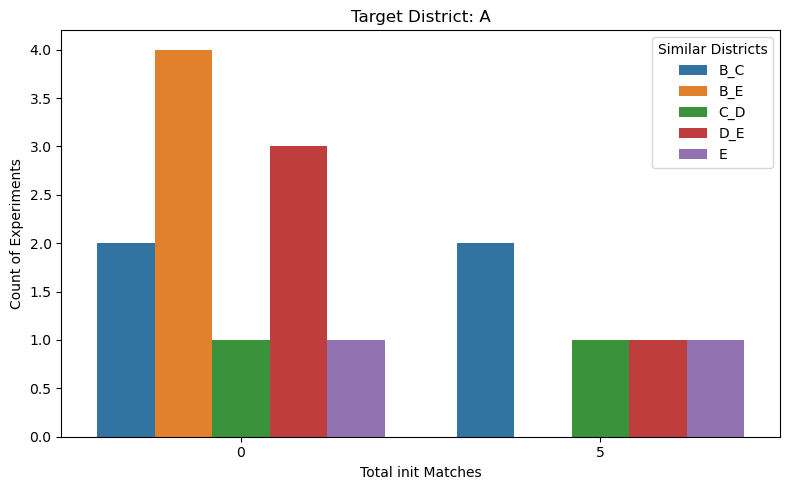

🏆 Best experiment per configuration (based on warm-up matches):


5


,max_initial_matches,exp_id,percentage
0,0,10,62.5
1,5,6,37.5


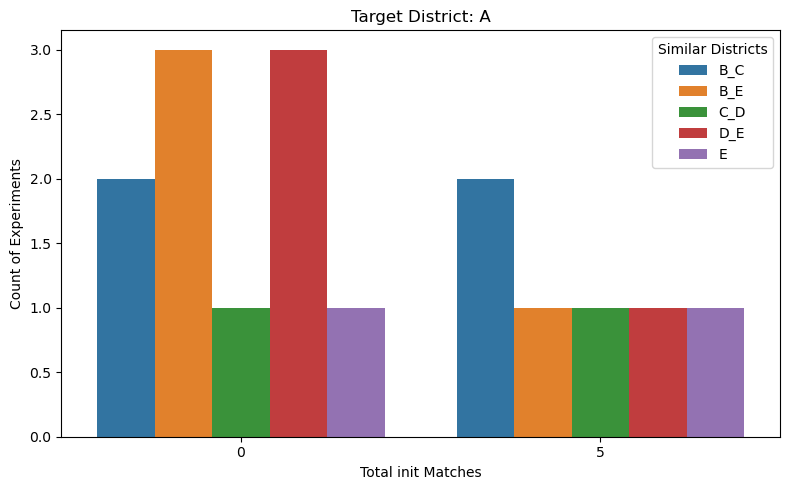

🏆 Best experiment per configuration (based on warm-up matches):


6


,max_initial_matches,exp_id,percentage
0,0,11,68.75
1,5,5,31.25


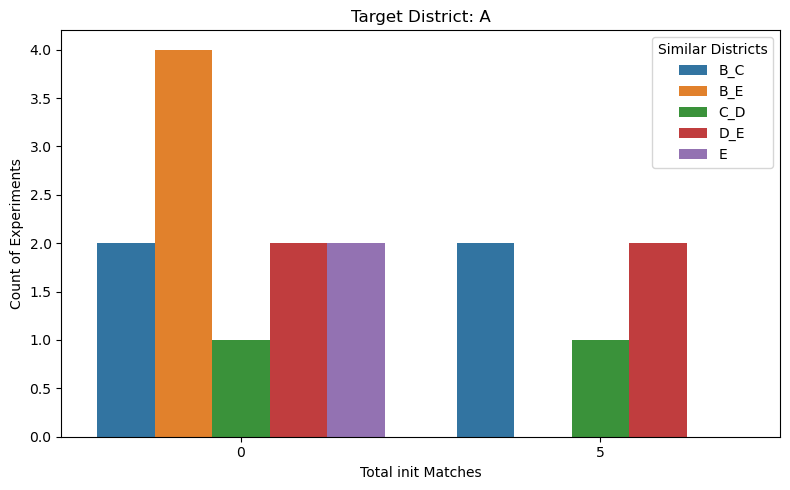

🏆 Best experiment per configuration (based on warm-up matches):


7


,max_initial_matches,exp_id,percentage
0,0,10,62.5
1,5,6,37.5


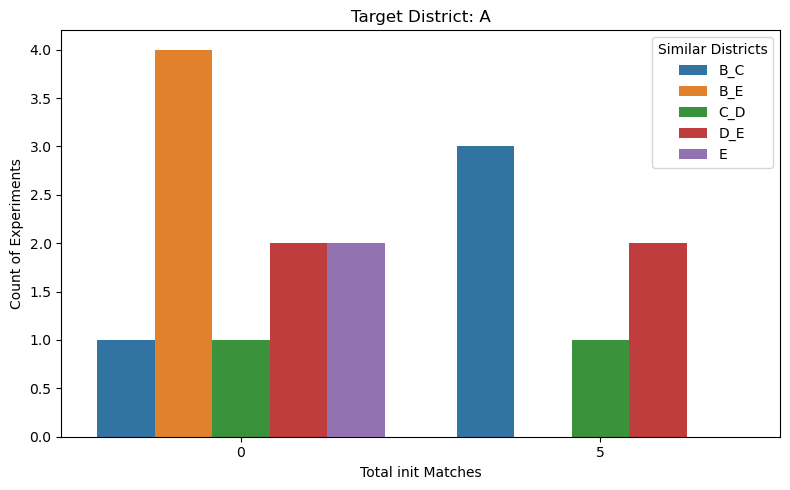

🏆 Best experiment per configuration (based on warm-up matches):


8


,max_initial_matches,exp_id,percentage
0,0,9,56.25
1,5,7,43.75


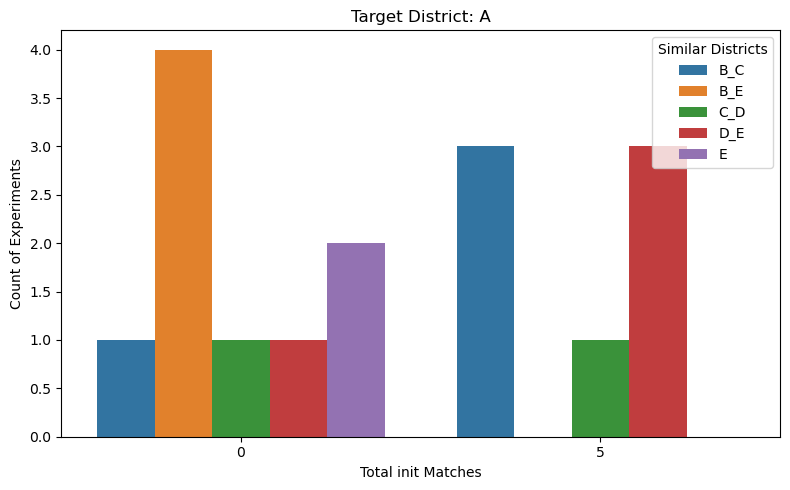

🏆 Best experiment per configuration (based on warm-up matches):


9


,max_initial_matches,exp_id,percentage
0,0,10,62.5
1,5,6,37.5


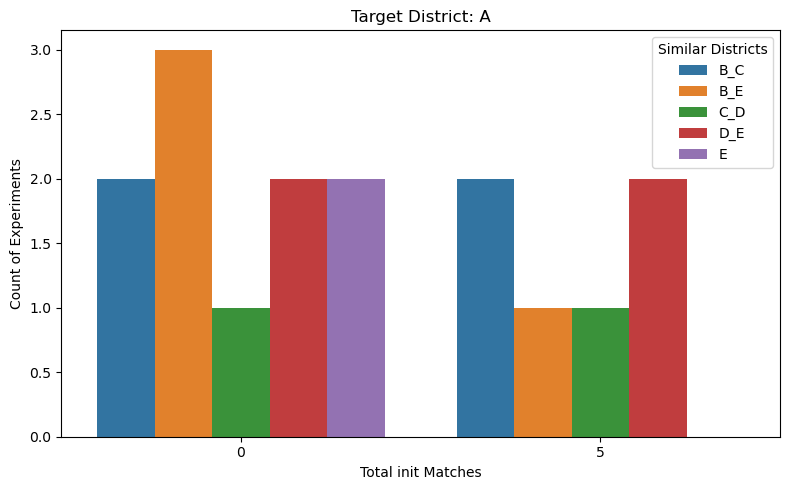

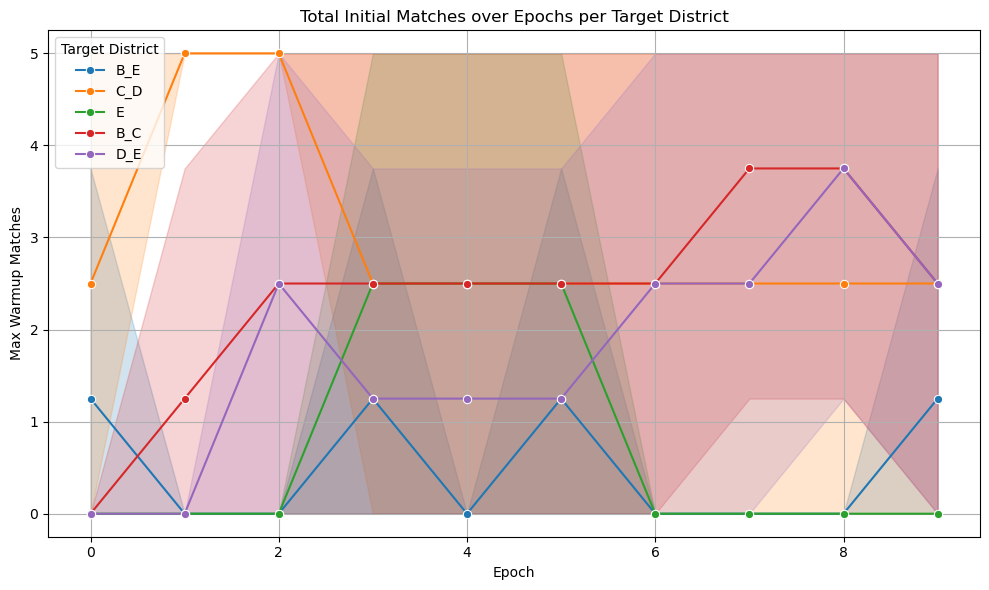

In [333]:
def analyze_init(results_id, proto_df, epoch_tgt = 0):

    info_state = get_similar_districts_from_path(results_id)
    tgt_client = results_id[0]

    results_tgt = proto_df[proto_df['epoch'] == str(epoch_tgt)]
    results_tgt = results_tgt[results_tgt['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['cosine'].rank(method='dense', ascending=True)

    results_tgt['test_metric'] = results_tgt['cosine'] + results_tgt['autocorr']
    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['test_metric'].rank(method='dense', ascending=True)

    
    top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

    summary = top_ranked.groupby(['label', 'client_2']).size().reset_index(name='count')
    summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

    # summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
    summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
    summary = summary.dropna(subset=['district_letter', 'label'])

    # Final-only match
    summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

    # Warm-up rule
    def match_with_warmup(row):
        if row['label'] < 3:
            return row['district_letter'] in info_state['initial_similar_districts']
        else:
            return row['district_letter'] in info_state['final_similar_districts']

    summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)


    # Summarize results
    total_final = summary['match_final_only'].sum()
    total_warmup = summary['match_warmup_rule'].sum()
        
    matches_per_epoch = summary.groupby('client_2')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
    max_final = matches_per_epoch['match_final_only'].max()
    max_warmup = matches_per_epoch['match_warmup_rule'].max()

    matches_per_epoch['experiment'] = results_id
    matches_per_epoch['max_final_matches'] = max_final
    matches_per_epoch['max_warmup_matches'] = max_warmup

    # return matches_per_epoch

    return {
        'experiment': results_id,
        'total_final_matches': total_final,
        'total_warmup_matches': total_warmup,
        'max_final_matches': max_final,
        'max_warmup_matches': max_warmup
    }         



def analyze_init(results_id, proto_df, epoch_tgt=0):
    info_state = get_similar_districts_from_path(results_id)
    tgt_client = results_id[0]

    results_tgt = proto_df[proto_df['epoch'] == str(epoch_tgt)]
    results_tgt = results_tgt[results_tgt['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['cosine'].rank(method='dense', ascending=True)
    
    # results_tgt['test_metric'] = results_tgt['cosine'] + results_tgt['autocorr']
    # results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['test_metric'].rank(method='dense', ascending=True)
    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['autocorr'].rank(method='dense', ascending=True)

    top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

    summary = top_ranked.groupby(['label', 'client_2']).size().reset_index(name='count')
    summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')
    summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
    summary = summary.dropna(subset=['district_letter', 'label'])

    ### 🔁 Change: Compare only against initial_similar_districts
    summary['match_initial_only'] = summary['district_letter'].isin(info_state['initial_similar_districts'])

    def match_with_initial_rule(row):
        return row['district_letter'] in info_state['initial_similar_districts']

    summary['match_initial_rule'] = summary.apply(match_with_initial_rule, axis=1)

    # return summary, top_ranked

    total_initial = summary['match_initial_only'].sum()
    total_initial_rule = summary['match_initial_rule'].sum()

    matches_per_epoch = summary.groupby('client_2')[['match_initial_only', 'match_initial_rule']].sum().reset_index()
    max_initial = matches_per_epoch['match_initial_only'].max()
    max_initial_rule = matches_per_epoch['match_initial_rule'].max()

    matches_per_epoch['experiment'] = results_id
    matches_per_epoch['max_initial_matches'] = max_initial
    matches_per_epoch['max_initial_rule_matches'] = max_initial_rule

    return {
        'experiment': results_id,
        'total_initial_matches': total_initial,
        'total_initial_rule_matches': total_initial_rule,
        'max_initial_matches': max_initial,
        'max_initial_rule_matches': max_initial_rule
    }

import pandas as pd
import os
import glob
from collections import defaultdict

CASE_TGT = 'NEW_WINDOW'

epoch_results = []


for ep_tgt in range(0,10):
    
    aux_protos = []
    for results_id in df_filtered['experiment'].unique():
        results_dir = f"results/{results_id}/Baseline_proto_initial.parquet"
        results_proto = pd.read_parquet(results_dir)
                
        result_init = analyze_init(results_id, proto_df=results_proto, epoch_tgt = ep_tgt)
        aux_protos.append(result_init)
    
    
    df_results = pd.DataFrame(aux_protos)
    
    def extract_exp_info(exp_id):
        try:
            parts = exp_id.split('__')
            target_header = parts[0]                     # 'E_15_LL_LM'
            mapping = parts[1]                           # 'LM_LL_LM_LL_LL'
    
            target_district = target_header.split('_')[0]     # 'E'
            node_id = target_header.split('_')[1]             # '15'
            init_state = target_header.split('_')[2]          # 'LL'
            final_state = target_header.split('_')[3]         # 'LM'
    
            aux_exp1 = exp_id.split('__')[-1]
            aux_exp2 = exp_id.split('__')[-2]
    
            return pd.Series([
                f"{target_district}_{node_id}",         # 'E_15'
                f"{init_state}_{final_state}",          # 'LL_LM'
                mapping[:14],                                 # 'LM_LL_LM_LL_LL'
                f"{aux_exp2}_{aux_exp1}"
            ])
        except Exception as e:
            print(f"Failed parsing exp_id: {exp_id} — {e}")
            return pd.Series([None, None, None])
    
    df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
        df_results['experiment'].apply(extract_exp_info)
    )
    
  
    
    # Get max warmup match for each unique config
    idx = df_results.groupby(
        ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
    )['total_initial_rule_matches'].idxmax()
    
    df_best_per_config = df_results.loc[idx].reset_index(drop=True)
    
    # Optional: sort by warmup performance
    df_best_per_config = df_best_per_config.sort_values(by='total_initial_rule_matches', ascending=False)
    
    
    df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
    df_best_per_config['target_initial_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-2]
    df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]
    
    df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)
    
    df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)
    
    def find_similar(row):
        target = df_best_per_config['target_district'][0]
        available_districts = [d for d in ['A', 'B', 'C', 'D', 'E'] if d != target]
        match_cols = [col for col in available_districts if row[col] == row['target_initial_state']]
        return '_'.join(match_cols)
    
    df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)

    df_best_per_config['epoch'] = ep_tgt
    epoch_results.append(df_best_per_config.copy())

    
    # Show results
    print("🏆 Best experiment per configuration (based on warm-up matches):")
    # df_best_per_config[['experiment', 'max_warmup_matches', 'target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']]
    
    
    df_plot = df_best_per_config[df_best_per_config['similar_districts'] != ''].groupby(['target_district', 'similar_districts', 'max_initial_matches']).agg({'exp_id' : 'count'}).reset_index()
    
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    
    tgt_dict = df_best_per_config['target_district'].unique().tolist()
    tgt_dict = sorted(tgt_dict)
    tgt_dict = [d for d in tgt_dict if d != '']

    print(f'\n\n{ep_tgt}')
    for tgt in tgt_dict:
        aux_plot = df_plot[df_plot['target_district'] == tgt]

        agg_df = aux_plot.groupby(['max_initial_matches']).agg({'exp_id': 'sum'}).reset_index()
        total = agg_df['exp_id'].sum()
        agg_df['percentage'] = (agg_df['exp_id'] / total) * 100
        display(agg_df)

        plt.figure(figsize=(8, 5))
        sns.barplot(
            data=aux_plot,
            x='max_initial_matches',
            y='exp_id',
            hue='similar_districts',
            # hue_order=['A', 'B', 'C', 'D', 'E']
        )
        plt.title(f'Target District: {tgt}')
        plt.xlabel('Total init Matches')
        plt.ylabel('Count of Experiments')
        plt.legend(title='Similar Districts')
        plt.tight_layout()
        plt.show()


df_all_epochs = pd.concat(epoch_results, ignore_index=True)

df_filter = df_all_epochs[df_all_epochs['similar_districts'] != '']

# df_agg = df_filter.groupby(['similar_districts', 'epoch']).agg({'total_warmup_matches' : 'sum'}).reset_index()
# case_counts = epoch_results[0]['similar_districts'].value_counts().reset_index()
# df_plot = pd.merge(df_agg, case_counts, on = 'similar_districts', how = 'left')
# df_plot['mean_matches'] = df_plot['total_warmup_matches'] / df_plot['count']

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_filter,
    x='epoch',
    y='max_initial_matches',
    hue='similar_districts',
    marker='o'
)
plt.title('Total Initial Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

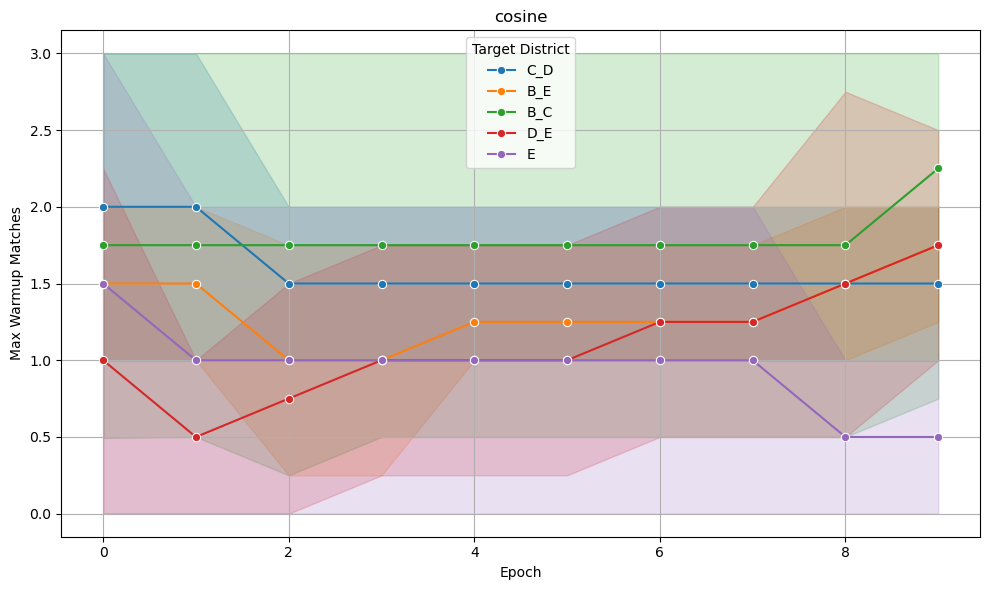

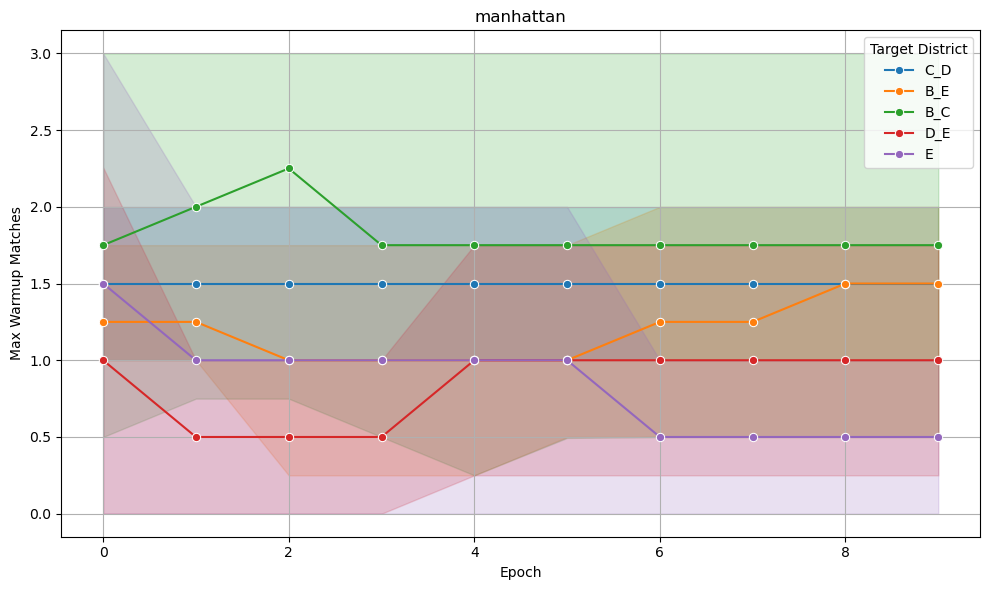

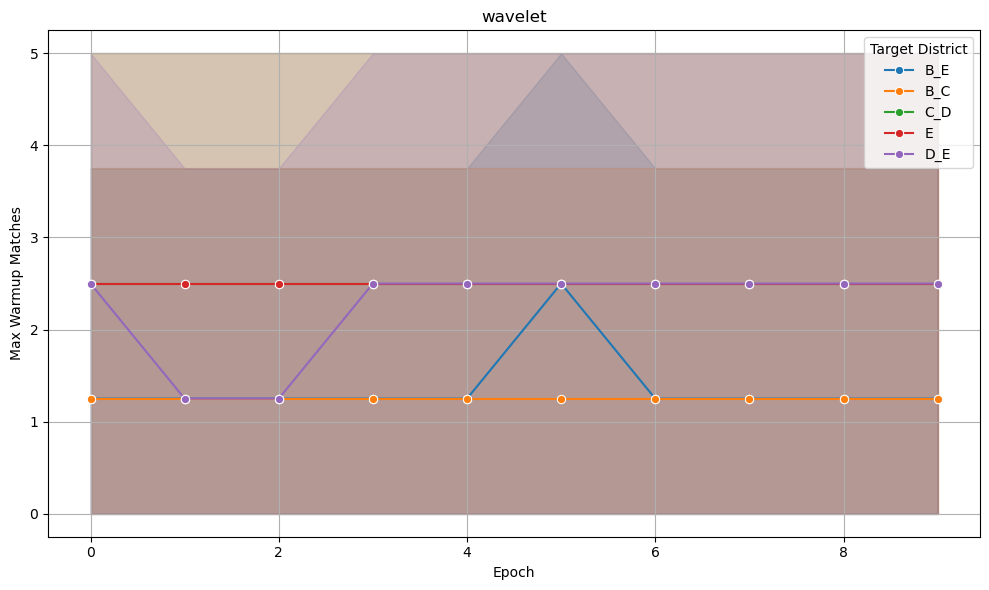

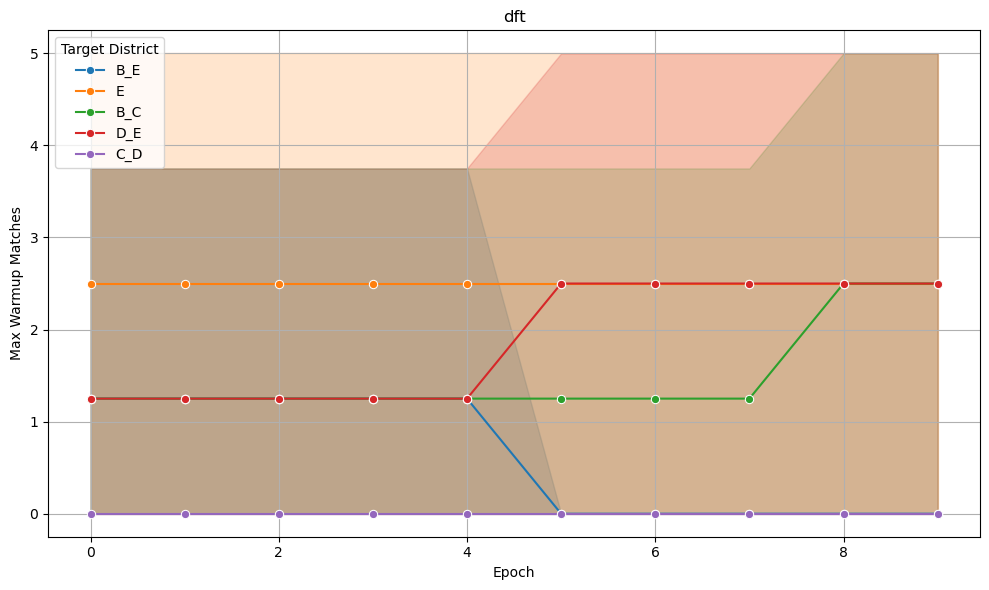

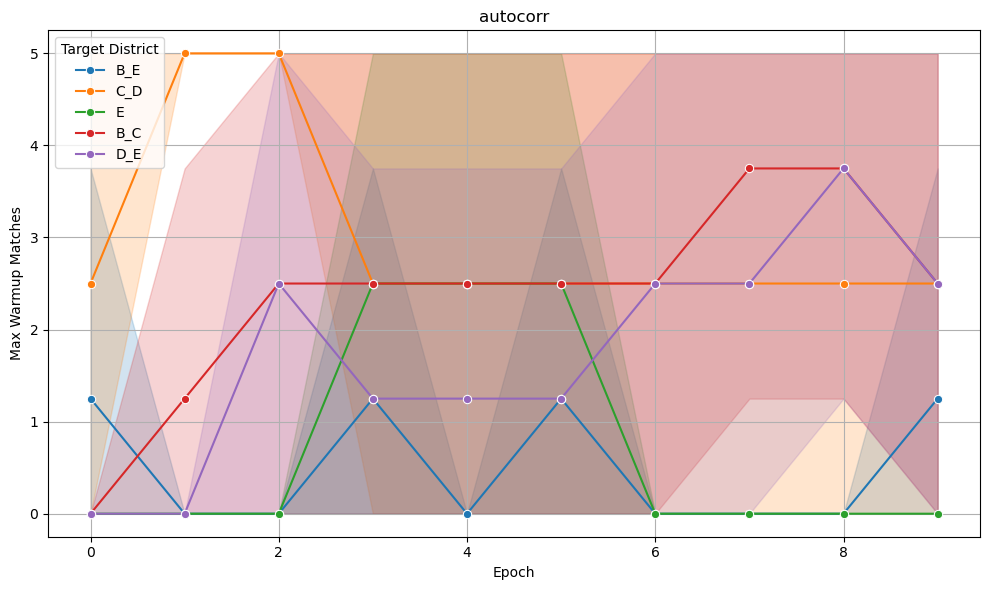

In [298]:
for metric in  ['cosine', 'manhattan', 'wavelet', 'dft', 'autocorr']:
    def analyze_init(results_id, proto_df, epoch_tgt=0):
        info_state = get_similar_districts_from_path(results_id)
        tgt_client = results_id[0]
    
        results_tgt = proto_df[proto_df['epoch'] == str(epoch_tgt)]
        results_tgt = results_tgt[results_tgt['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

        results_tgt['cosine_rank'] = results_tgt.groupby(['label'])[metric].rank(method='dense', ascending=True)
    
        top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]
    
        summary = top_ranked.groupby(['label', 'client_2']).size().reset_index(name='count')
        summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')
        summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
        summary = summary.dropna(subset=['district_letter', 'label'])
    
        ### 🔁 Change: Compare only against initial_similar_districts
        summary['match_initial_only'] = summary['district_letter'].isin(info_state['initial_similar_districts'])
    
        def match_with_initial_rule(row):
            return row['district_letter'] in info_state['initial_similar_districts']
    
        summary['match_initial_rule'] = summary.apply(match_with_initial_rule, axis=1)
    
        # return summary, top_ranked
    
        total_initial = summary['match_initial_only'].sum()
        total_initial_rule = summary['match_initial_rule'].sum()
    
        matches_per_epoch = summary.groupby('client_2')[['match_initial_only', 'match_initial_rule']].sum().reset_index()
        max_initial = matches_per_epoch['match_initial_only'].max()
        max_initial_rule = matches_per_epoch['match_initial_rule'].max()
    
        matches_per_epoch['experiment'] = results_id
        matches_per_epoch['max_initial_matches'] = max_initial
        matches_per_epoch['max_initial_rule_matches'] = max_initial_rule
    
        return {
            'experiment': results_id,
            'total_initial_matches': total_initial,
            'total_initial_rule_matches': total_initial_rule,
            'max_initial_matches': max_initial,
            'max_initial_rule_matches': max_initial_rule
        }
    
   
    CASE_TGT = 'NEW_WINDOW'
    
    epoch_results = []
    
    
    for ep_tgt in range(0,10):
        
        aux_protos = []
        for results_id in df_filtered['experiment'].unique():
            results_dir = f"results/{results_id}/Baseline_proto_initial.parquet"
            results_proto = pd.read_parquet(results_dir)
                    
            result_init = analyze_init(results_id, proto_df=results_proto, epoch_tgt = ep_tgt)
            aux_protos.append(result_init)
        
        
        df_results = pd.DataFrame(aux_protos)
        
        def extract_exp_info(exp_id):
            try:
                parts = exp_id.split('__')
                target_header = parts[0]                     # 'E_15_LL_LM'
                mapping = parts[1]                           # 'LM_LL_LM_LL_LL'
        
                target_district = target_header.split('_')[0]     # 'E'
                node_id = target_header.split('_')[1]             # '15'
                init_state = target_header.split('_')[2]          # 'LL'
                final_state = target_header.split('_')[3]         # 'LM'
        
                aux_exp1 = exp_id.split('__')[-1]
                aux_exp2 = exp_id.split('__')[-2]
        
                return pd.Series([
                    f"{target_district}_{node_id}",         # 'E_15'
                    f"{init_state}_{final_state}",          # 'LL_LM'
                    mapping[:14],                                 # 'LM_LL_LM_LL_LL'
                    f"{aux_exp2}_{aux_exp1}"
                ])
            except Exception as e:
                print(f"Failed parsing exp_id: {exp_id} — {e}")
                return pd.Series([None, None, None])
        
        df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
            df_results['experiment'].apply(extract_exp_info)
        )
        
      
        
        # Get max warmup match for each unique config
        idx = df_results.groupby(
            ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
        )['total_initial_rule_matches'].idxmax()
        
        df_best_per_config = df_results.loc[idx].reset_index(drop=True)
        
        # Optional: sort by warmup performance
        df_best_per_config = df_best_per_config.sort_values(by='total_initial_rule_matches', ascending=False)
        
        
        df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
        df_best_per_config['target_initial_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-2]
        df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]
        
        df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)
        
        df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)
        
        def find_similar(row):
            target = df_best_per_config['target_district'][0]
            available_districts = [d for d in ['A', 'B', 'C', 'D', 'E'] if d != target]
            match_cols = [col for col in available_districts if row[col] == row['target_initial_state']]
            return '_'.join(match_cols)
        
        df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)
    
        df_best_per_config['epoch'] = ep_tgt
        epoch_results.append(df_best_per_config.copy())

    df_all_epochs = pd.concat(epoch_results, ignore_index=True)
    
    df_filter = df_all_epochs[df_all_epochs['similar_districts'] != '']
    
    # df_agg = df_filter.groupby(['similar_districts', 'epoch']).agg({'total_warmup_matches' : 'sum'}).reset_index()
    # case_counts = epoch_results[0]['similar_districts'].value_counts().reset_index()
    # df_plot = pd.merge(df_agg, case_counts, on = 'similar_districts', how = 'left')
    # df_plot['mean_matches'] = df_plot['total_warmup_matches'] / df_plot['count']
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_filter,
        x='epoch',
        y='max_initial_matches',
        hue='similar_districts',
        marker='o'
    )
    plt.title(metric)
    plt.xlabel('Epoch')
    plt.ylabel('Max Warmup Matches')
    plt.legend(title='Target District')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [276]:
def analyze_init_debug(results_id, proto_df, epoch_tgt = 0):

    info_state = get_similar_districts_from_path(results_id)
    tgt_client = results_id[0]

    results_tgt = proto_df[proto_df['epoch'] == str(epoch_tgt)]
    results_tgt = results_tgt[results_tgt['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['cosine'].rank(method='dense', ascending=True)

    # results_tgt['test_metric'] = results_tgt['cosine'] + results_tgt['autocorr']
    # results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['test_metric'].rank(method='dense', ascending=True)

    top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

    summary = top_ranked.groupby(['label', 'client_2']).size().reset_index(name='count')
    summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

    # summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
    summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
    summary = summary.dropna(subset=['district_letter', 'label'])

    # Final-only match
    summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

    # Warm-up rule
    def match_with_warmup(row):
        if row['label'] < 3:
            return row['district_letter'] in info_state['initial_similar_districts']
        else:
            return row['district_letter'] in info_state['final_similar_districts']

    summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

    # return summary, info_state
    
    # Summarize results
    total_final = summary['match_final_only'].sum()
    total_warmup = summary['match_warmup_rule'].sum()
        
    matches_per_epoch = summary.groupby('client_2')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
    max_final = matches_per_epoch['match_final_only'].max()
    max_warmup = matches_per_epoch['match_warmup_rule'].max()

    matches_per_epoch['experiment'] = results_id
    matches_per_epoch['max_final_matches'] = max_final
    matches_per_epoch['max_warmup_matches'] = max_warmup

    # return matches_per_epoch

    return {
        'experiment': results_id,
        'total_final_matches': total_final,
        'total_warmup_matches': total_warmup,
        'max_final_matches': max_final,
        'max_warmup_matches': max_warmup
    }     



def analyze_init_debug(results_id, proto_df, epoch_tgt=0):
    info_state = get_similar_districts_from_path(results_id)
    tgt_client = results_id[0]

    results_tgt = proto_df[proto_df['epoch'] == str(epoch_tgt)]
    results_tgt = results_tgt[results_tgt['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

    results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['cosine'].rank(method='dense', ascending=True)
    
    # results_tgt['test_metric'] = results_tgt['cosine'] + results_tgt['autocorr']
    # results_tgt['cosine_rank'] = results_tgt.groupby(['label'])['test_metric'].rank(method='dense', ascending=True)

    top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

    summary = top_ranked.groupby(['label', 'client_2']).size().reset_index(name='count')
    summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')
    summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
    summary = summary.dropna(subset=['district_letter', 'label'])

    ### 🔁 Change: Compare only against initial_similar_districts
    summary['match_initial_only'] = summary['district_letter'].isin(info_state['initial_similar_districts'])

    def match_with_initial_rule(row):
        return row['district_letter'] in info_state['initial_similar_districts']

    summary['match_initial_rule'] = summary.apply(match_with_initial_rule, axis=1)

    return summary, top_ranked

    total_initial = summary['match_initial_only'].sum()
    total_initial_rule = summary['match_initial_rule'].sum()

    matches_per_epoch = summary.groupby('client_2')[['match_initial_only', 'match_initial_rule']].sum().reset_index()
    max_initial = matches_per_epoch['match_initial_only'].max()
    max_initial_rule = matches_per_epoch['match_initial_rule'].max()

    matches_per_epoch['experiment'] = results_id
    matches_per_epoch['max_initial_matches'] = max_initial
    matches_per_epoch['max_initial_rule_matches'] = max_initial_rule

    return {
        'experiment': results_id,
        'total_initial_matches': total_initial,
        'total_initial_rule_matches': total_initial_rule,
        'max_initial_matches': max_initial,
        'max_initial_rule_matches': max_initial_rule
    }


for results_id in [df_best_per_config.loc[110]['experiment']] :# df_filtered['experiment'].unique():
    results_dir = f"results/{results_id}/Baseline_proto_initial.parquet"
    results_proto = pd.read_parquet(results_dir)
            
    result_init = analyze_init_debug(results_id, proto_df=results_proto, epoch_tgt = ep_tgt)
    break

KeyError: 110

In [ ]:
results_id

In [ ]:
result_init[0]

In [ ]:
result_init[1]

In [293]:
 ['cosine', 'manhattan', 'wavelet', 'dft', 'autocorr']

Index(['epoch', 'label', 'client_1', 'client_2', 'cosine', 'manhattan',
       'wavelet', 'dft', 'autocorr'],
      dtype='object')

In [250]:
filter_init = results_proto[results_proto['client_1'] == 'District_A__proto']

for epoch in filter_init['epoch'].unique():
    display(filter_init[(filter_init['epoch'] == epoch) & (filter_init['label'] == 0)].sort_values(by='cosine'))

,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
0,0,0,District_A__proto,District_B__proto,0.000420,0.100817,0.281703,0.090091,1.05
2,0,0,District_A__proto,District_D__proto,0.000794,0.164212,0.331799,0.095935,0.30
3,0,0,District_A__proto,District_E__proto,0.000889,0.159716,0.274407,0.091727,0.55
1,0,0,District_A__proto,District_C__proto,0.001116,0.197129,0.479865,0.121575,0.25


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
60,1,0,District_A__proto,District_B__proto,0.000420,0.118240,0.302741,0.092896,1.20
62,1,0,District_A__proto,District_D__proto,0.000732,0.172256,0.350315,0.099234,0.60
63,1,0,District_A__proto,District_E__proto,0.000840,0.162162,0.289527,0.096394,0.75
61,1,0,District_A__proto,District_C__proto,0.000972,0.207766,0.493569,0.124692,0.45


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
120,2,0,District_A__proto,District_B__proto,0.000226,0.133086,0.327661,0.095258,1.00
122,2,0,District_A__proto,District_D__proto,0.000385,0.171462,0.354852,0.100339,0.45
123,2,0,District_A__proto,District_E__proto,0.000450,0.171344,0.305025,0.098237,0.70
121,2,0,District_A__proto,District_C__proto,0.000496,0.201633,0.478689,0.121583,0.55


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
180,3,0,District_A__proto,District_B__proto,0.000197,0.131709,0.329742,0.095196,0.95
182,3,0,District_A__proto,District_D__proto,0.000330,0.164560,0.347509,0.098738,0.55
183,3,0,District_A__proto,District_E__proto,0.000400,0.170021,0.303259,0.097374,0.70
181,3,0,District_A__proto,District_C__proto,0.000422,0.192409,0.460839,0.119171,0.60


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
240,4,0,District_A__proto,District_B__proto,0.000210,0.131919,0.329475,0.095302,0.90
242,4,0,District_A__proto,District_D__proto,0.000339,0.160498,0.343209,0.097628,0.45
243,4,0,District_A__proto,District_E__proto,0.000418,0.166233,0.298253,0.096350,0.75
241,4,0,District_A__proto,District_C__proto,0.000440,0.189782,0.457336,0.119572,0.55


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
300,5,0,District_A__proto,District_B__proto,0.000218,0.131313,0.328882,0.095480,1.00
302,5,0,District_A__proto,District_D__proto,0.000342,0.158449,0.340779,0.097054,0.50
303,5,0,District_A__proto,District_E__proto,0.000425,0.164406,0.295904,0.095940,0.70
301,5,0,District_A__proto,District_C__proto,0.000456,0.190706,0.460714,0.120733,0.65


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
360,6,0,District_A__proto,District_B__proto,0.000217,0.130381,0.327683,0.095565,1.15
362,6,0,District_A__proto,District_D__proto,0.000337,0.156993,0.339207,0.096823,0.45
363,6,0,District_A__proto,District_E__proto,0.000423,0.163921,0.295471,0.096151,0.75
361,6,0,District_A__proto,District_C__proto,0.000462,0.192630,0.466901,0.122095,0.65


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
420,7,0,District_A__proto,District_B__proto,0.000217,0.129850,0.327430,0.096114,1.15
422,7,0,District_A__proto,District_D__proto,0.000333,0.156409,0.340072,0.097268,0.40
423,7,0,District_A__proto,District_E__proto,0.000419,0.164274,0.296555,0.096883,0.85
421,7,0,District_A__proto,District_C__proto,0.000466,0.195528,0.476035,0.123952,0.55


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
480,8,0,District_A__proto,District_B__proto,0.000218,0.129626,0.328127,0.097179,1.25
482,8,0,District_A__proto,District_D__proto,0.000331,0.156989,0.343218,0.098309,0.50
483,8,0,District_A__proto,District_E__proto,0.000416,0.166017,0.298450,0.097937,0.90
481,8,0,District_A__proto,District_C__proto,0.000474,0.199953,0.488499,0.126535,0.60


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
540,9,0,District_A__proto,District_B__proto,0.000223,0.129619,0.328973,0.098532,1.25
542,9,0,District_A__proto,District_D__proto,0.000334,0.157995,0.348023,0.099774,0.45
543,9,0,District_A__proto,District_E__proto,0.000417,0.168533,0.301009,0.099247,0.90
541,9,0,District_A__proto,District_C__proto,0.000489,0.205459,0.504043,0.129833,0.65


In [125]:
test = filter_init[(filter_init['epoch'] == '9') & (filter_init['label'] == 0)].copy()
test['test_metric'] = test['cosine']# + test['autocorr']
test['cosine_rank'] = test.groupby(['label'])['test_metric'].rank(method='dense', ascending=True)


top_ranked = test[test['cosine_rank'] == 1]
top_ranked

,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr,test_metric,cosine_rank
2160,9,0,District_A__proto,District_B__proto,0.000223,0.129619,0.551112,0.383019,0.197797,0.000223,1.0


In [24]:
proto_init = pd.concat(all_protos[scenario], ignore_index=True)
result_init = analyze_init(results_id, proto_df=proto_init, epoch_tgt = ep_tgt)
result_init

,label,client_2,count,district_letter,match_final_only,match_warmup_rule
0,0,District_C__proto,1,C,False,True
1,1,District_C__proto,1,C,False,True
2,2,District_C__proto,1,C,False,True


In [96]:
filter_init = proto_init[proto_init['client_1'] == 'District_A__proto']

for epoch in filter_init['epoch'].unique():
    display(filter_init[(filter_init['epoch'] == epoch) & (filter_init['label'] == 0)].sort_values(by='cosine'))

,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
1,0,0,District_A__proto,District_C__proto,0.004120,0.387131,0.752579,0.205089,0.65
3,0,0,District_A__proto,District_E__proto,0.006900,0.465710,1.035800,0.297170,0.85
0,0,0,District_A__proto,District_B__proto,0.007125,0.477921,1.094961,0.316595,0.60
2,0,0,District_A__proto,District_D__proto,0.019879,0.804391,1.786639,0.495430,0.60


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
61,1,0,District_A__proto,District_C__proto,0.004120,0.387895,0.751674,0.202640,0.55
63,1,0,District_A__proto,District_E__proto,0.007062,0.470717,1.042269,0.298849,0.90
60,1,0,District_A__proto,District_B__proto,0.007213,0.481331,1.098912,0.317211,0.55
62,1,0,District_A__proto,District_D__proto,0.019923,0.796677,1.769962,0.492708,0.65


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
121,2,0,District_A__proto,District_C__proto,0.003928,0.387887,0.750380,0.199770,0.80
123,2,0,District_A__proto,District_E__proto,0.006984,0.477425,1.051387,0.302526,0.80
120,2,0,District_A__proto,District_B__proto,0.007021,0.484129,1.105054,0.320018,0.65
122,2,0,District_A__proto,District_D__proto,0.018986,0.783874,1.743813,0.491395,0.60


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
181,3,0,District_A__proto,District_C__proto,0.003557,0.386824,0.747715,0.197108,0.95
180,3,0,District_A__proto,District_B__proto,0.006528,0.484901,1.109239,0.324755,0.60
183,3,0,District_A__proto,District_E__proto,0.006593,0.485820,1.062658,0.307348,0.85
182,3,0,District_A__proto,District_D__proto,0.017261,0.784504,1.740412,0.492593,0.55


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
241,4,0,District_A__proto,District_C__proto,0.003162,0.385468,0.744825,0.195275,0.80
240,4,0,District_A__proto,District_B__proto,0.005966,0.484682,1.113941,0.331461,0.55
243,4,0,District_A__proto,District_E__proto,0.006092,0.494102,1.075868,0.312864,0.70
242,4,0,District_A__proto,District_D__proto,0.015492,0.787528,1.746277,0.497716,0.60


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
301,5,0,District_A__proto,District_C__proto,0.002822,0.383691,0.741326,0.194054,0.85
300,5,0,District_A__proto,District_B__proto,0.005453,0.490292,1.122146,0.338366,0.65
303,5,0,District_A__proto,District_E__proto,0.005614,0.500752,1.087656,0.317935,0.65
302,5,0,District_A__proto,District_D__proto,0.013979,0.793226,1.756252,0.504436,0.60


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
361,6,0,District_A__proto,District_C__proto,0.002562,0.382043,0.738093,0.193318,0.7
360,6,0,District_A__proto,District_B__proto,0.005048,0.503184,1.143979,0.345365,0.6
363,6,0,District_A__proto,District_E__proto,0.005235,0.506429,1.098966,0.323001,0.7
362,6,0,District_A__proto,District_D__proto,0.012825,0.809516,1.791548,0.512427,0.7


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
421,7,0,District_A__proto,District_C__proto,0.002371,0.380483,0.734995,0.192869,0.85
420,7,0,District_A__proto,District_B__proto,0.004735,0.512724,1.162442,0.351799,0.65
423,7,0,District_A__proto,District_E__proto,0.004942,0.510932,1.108650,0.327640,0.70
422,7,0,District_A__proto,District_D__proto,0.011950,0.821063,1.816456,0.520315,0.55


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
481,8,0,District_A__proto,District_C__proto,0.002232,0.379186,0.732390,0.192612,0.95
480,8,0,District_A__proto,District_B__proto,0.004496,0.518492,1.175497,0.357500,0.70
483,8,0,District_A__proto,District_E__proto,0.004720,0.514540,1.116624,0.331766,0.65
482,8,0,District_A__proto,District_D__proto,0.011286,0.828750,1.832827,0.527515,0.50


,epoch,label,client_1,client_2,cosine,manhattan,wavelet,dft,autocorr
541,9,0,District_A__proto,District_C__proto,0.002128,0.377721,0.729482,0.192254,0.90
540,9,0,District_A__proto,District_B__proto,0.004311,0.520824,1.182799,0.361807,0.70
543,9,0,District_A__proto,District_E__proto,0.004543,0.516689,1.121616,0.334757,0.65
542,9,0,District_A__proto,District_D__proto,0.010779,0.832537,1.840618,0.533053,0.50


array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [86]:
df_filtered.loc[16]

experiment              A_62_LL_LM__LL_LL_LL_LH_LM_10_1_12_9_NEW_WINDO...
total_final_matches                                                    24
total_warmup_matches                                                   21
max_final_matches                                                      24
max_warmup_matches                                                     21
exp_id                                                       9_6_43200__0
target_district                                                         A
target_final_state                                                     LM
A                                                                      LL
B                                                                      LL
C                                                                      LL
D                                                                      LH
E                                                                      LM
similar_districts                     